# PASTIS Subset: Exploration, Split and Model Training

Crop-type classification assignment (Solafune). This notebook covers:
- **Task B, exploratory data analysis** (Sections 1–8),
- **Task C, train / validation / test split** (Section 9),
- **Task D, model training** (Section 10): results of `python -m src.train`, compared on the validation split.
- **Task E, model evaluation** (Section 11): validation and test scores from `python -m src.evaluate`,
  confusion matrices, stability and error analysis,
- **Task F, visualisation of outputs** (Section 12): RGB / ground truth / prediction / error maps for test patches.

Dataset: 102 Sentinel-2 patches (128 × 128 px, 10 bands, a fixed 46-observation time series shared by all patches) with
single-layer semantic labels from the PASTIS benchmark (tile T31TFM, France). Reusable code lives in `src/`, settings
in `configs/config.yaml`. Run the notebook with the project environment (`.venv`, see `requirements.txt`).

In [1]:
import sys
sys.path.insert(0, '..')

import json
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Image as StaticImage, display

from src.data_loading import PastisSubset, discover_patch_ids, class_pixel_counts, S2_BAND_NAMES, CLASS_NAMES
from src.preprocessing import to_reflectance, normalized_difference
from src.visualization import (
    register_template, s2_composite, label_heatmap, style_image_axes, with_alpha,
    SERIES, SEQUENTIAL_BLUE, GRIDLINE, SURFACE, INK_MUTED,
    TRUE_COLOR, COLOR_INFRARED, SWIR_AGRICULTURE,
)

DATA_ROOT = '../PASTIS_subset'
FIG_DIR = '../outputs/figures'
METRICS_DIR = '../outputs/metrics'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

register_template()

## 1. Dataset inventory

Cross-check that every patch has both a Sentinel-2 file and an annotation file, and load the metadata table.

In [2]:
patch_ids = discover_patch_ids(DATA_ROOT)
ds = PastisSubset(DATA_ROOT)

print(f"Number of image patches: {len(patch_ids)}")
print(f"Patch IDs match between DATA_S2 and ANNOTATIONS: {patch_ids == ds.patch_ids}")
ds.metadata.drop(columns=['dates', 'geometry']).head()


Number of image patches: 102
Patch IDs match between DATA_S2 and ANNOTATIONS: True


,Fold,ID_PATCH,N_Parcel,Parcel_Cover,TILE,id,n_dates
0,2,30003,82,0.679651,t31tfm,30003,46
1,1,30013,46,0.939360,t31tfm,30013,46
2,2,30014,61,0.688851,t31tfm,30014,46
3,3,30023,57,0.674748,t31tfm,30023,46
4,3,30026,48,0.606728,t31tfm,30026,46


In [4]:
# patch_ids

In [4]:
n_unique_classes_per_patch = {
    pid: len(np.unique(ds.load_target(pid)[0]))
    for pid in patch_ids
}
pd.Series(n_unique_classes_per_patch, name='n_unique_classes').describe()


count    102.000000
mean       8.019608
std        1.281864
min        4.000000
25%        7.000000
50%        8.000000
75%        9.000000
max       11.000000
Name: n_unique_classes, dtype: float64

In [ ]:
# n_unique_classes_per_patch
# ds.metadata['TILE'].nunique()
# ds.metadata['Fold'].nunique()


## 2. Image dimensions and Sentinel-2 band structure

Inspect array shapes/dtypes across **all** patches (not just one) to confirm what's fixed vs. variable.

In [7]:
records = []
for pid in patch_ids:
    s2 = ds.load_s2(pid)
    tgt = ds.load_target(pid)
    records.append({
        'patch_id': pid,
        'n_obs': s2.shape[0],
        'n_bands': s2.shape[1],
        'height': s2.shape[2],
        'width': s2.shape[3],
        's2_dtype': str(s2.dtype),
        's2_min': int(s2.min()),
        's2_max': int(s2.max()),
        'target_shape': tgt.shape,
        'target_dtype': str(tgt.dtype),
    })

shape_df = pd.DataFrame(records)
shape_df.to_csv(f'{METRICS_DIR}/patch_shape_summary.csv', index=False)

print("Height/width values found:", shape_df[['height','width']].drop_duplicates().values.tolist())
print("Observation values found:", shape_df['n_obs'].unique().tolist())
print("Band count values found:", shape_df['n_bands'].unique().tolist())
print("S2 dtype(s):", shape_df['s2_dtype'].unique().tolist())
print("S2 pixel value range across dataset: [%d, %d]" % (shape_df['s2_min'].min(), shape_df['s2_max'].max()))
print("Target dtype(s):", shape_df['target_dtype'].unique().tolist())
print()
print("Sentinel-2 band order (10 bands):")
for i, b in enumerate(S2_BAND_NAMES):
    print(f"  {i}: {b}")


Height/width values found: [[128, 128]]
Observation values found: [46]
Band count values found: [10]
S2 dtype(s): ['int16']
S2 pixel value range across dataset: [-601, 20716]
Target dtype(s): ['uint8']

Sentinel-2 band order (10 bands):
  0: B2
  1: B3
  2: B4
  3: B5
  4: B6
  5: B7
  6: B8
  7: B8A
  8: B11
  9: B12


**Observations:**
- All 102 patches are fixed at **128x128 px** with **10 bands** — spatially consistent.
- `number_of_observations` (time steps) is **46 for every single patch** (see Section 3) — a fixed-length sequence, not variable as one might initially assume from PASTIS documentation. This simplifies modeling: no padding/masking of ragged sequences is needed.
- Sentinel-2 reflectance is stored as **raw digital numbers (int16)**, not scaled to [0,1] reflectance — needs normalization before modeling.
- Targets are `uint8`, single layer, per the assignment brief.


### 2b. Reflectance value ranges per band

A single streaming pass over all 102 patches (one patch in memory at a time) collects what the next sections need:
per-band value distributions (200 random pixels × 46 dates per patch), the share of out-of-range digital numbers (DN),
a per-date cloud proxy, and NDVI time series for up to 200 random pixels per class per patch.

In [8]:
rng = np.random.default_rng(0)
PIXELS_PER_PATCH = 200
NDVI_PIXELS_PER_CLASS = 200
BRIGHT_BLUE_DN = 2000          # B2 reflectance > 0.20 -> bright, cloud/haze-like pixel

n_dates = int(shape_df['n_obs'].iloc[0])
band_samples, ndvi_samples = [], {c: [] for c in CLASS_NAMES}
n_negative = np.zeros(len(S2_BAND_NAMES), dtype=np.int64)
n_above_10000 = np.zeros(len(S2_BAND_NAMES), dtype=np.int64)
bright_fraction = np.zeros((len(patch_ids), n_dates))      # patch x date

for i, pid in enumerate(patch_ids):
    s2 = ds.load_s2(pid)
    flat = s2.reshape(s2.shape[0], s2.shape[1], -1)         # (T, B, pixels)
    tgt = ds.load_target(pid).ravel()
    n_negative += (flat < 0).sum(axis=(0, 2))
    n_above_10000 += (flat > 10000).sum(axis=(0, 2))
    pix = rng.choice(flat.shape[2], PIXELS_PER_PATCH, replace=False)
    band_samples.append(flat[:, :, pix].transpose(0, 2, 1).reshape(-1, flat.shape[1]))
    bright_fraction[i] = (flat[:, 0] > BRIGHT_BLUE_DN).mean(axis=1)
    ndvi = normalized_difference(to_reflectance(s2, 10000.0, (0.0, 1.0)), 'B8', 'B4').reshape(n_dates, -1)
    for c in np.unique(tgt):
        members = np.flatnonzero(tgt == c)
        take = rng.choice(members, min(NDVI_PIXELS_PER_CLASS, members.size), replace=False)
        ndvi_samples[int(c)].append(ndvi[:, take].T)

n_values = len(patch_ids) * n_dates * flat.shape[2]
band_samples = np.concatenate(band_samples) / 10000
ndvi_samples = {c: np.concatenate(v) for c, v in ndvi_samples.items() if v}
print(f'Band sample: {band_samples.shape[0]:,} pixel-dates. NDVI series sampled for {len(ndvi_samples)} classes.')

Band sample: 938,400 pixel-dates. NDVI series sampled for 19 classes.


In [9]:
WAVELENGTH_NM = [490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]
q = np.percentile(band_samples, [1, 25, 50, 75, 99], axis=0)
band_stats = pd.DataFrame({
    'band': S2_BAND_NAMES, 'wavelength_nm': WAVELENGTH_NM,
    'mean': band_samples.mean(axis=0), 'std': band_samples.std(axis=0),
    'p1': q[0], 'median': q[2], 'p99': q[4],
    'pct_negative_dn': 100 * n_negative / n_values,
    'pct_above_10000_dn': 100 * n_above_10000 / n_values,
}).round(4)
band_stats.to_csv(f'{METRICS_DIR}/band_statistics.csv', index=False)

fig = go.Figure(go.Box(
    x=[f'{b}<br>{w} nm' for b, w in zip(S2_BAND_NAMES, WAVELENGTH_NM)],
    q1=q[1], median=q[2], q3=q[3], lowerfence=q[0], upperfence=q[4],
    marker_color=SERIES[0], line=dict(width=1.5), fillcolor=with_alpha(SERIES[0], 0.10),
))
fig.update_layout(
    title='Surface reflectance per band (box: interquartile range, whiskers: 1st–99th percentile)',
    xaxis_title='Sentinel-2 band (central wavelength)', yaxis_title='Reflectance (DN / 10,000)',
    showlegend=False, width=950, height=430,
)
fig.write_image(f'{FIG_DIR}/band_reflectance_distribution.png', scale=2)
fig.show()
band_stats

,band,wavelength_nm,mean,std,p1,median,p99,pct_negative_dn,pct_above_10000_dn
0,B2,490,0.1242,0.1909,0.0000,0.0474,0.8241,0.0000,0.2228
1,B3,560,0.1450,0.1838,0.0000,0.0732,0.8263,0.0000,0.2339
2,B4,665,0.1496,0.1921,0.0000,0.0749,0.8494,0.0000,0.3001
3,B5,705,0.1834,0.1798,0.0064,0.1186,0.8474,0.0000,0.2935
4,B6,740,0.2847,0.1639,0.0298,0.2470,0.8711,0.0000,0.3460
5,B7,783,0.3216,0.1650,0.0365,0.2888,0.8814,0.0000,0.3744
6,B8,842,0.3312,0.1662,0.0334,0.3019,0.8810,0.0000,0.3644
7,B8A,865,0.3482,0.1638,0.0397,0.3214,0.8889,0.0000,0.3996
8,B11,1610,0.2556,0.1341,0.0218,0.2246,0.6856,0.0962,0.0151
9,B12,2190,0.1716,0.1190,0.0111,0.1347,0.5508,0.0000,0.0001


**Observations:**
- Values are surface reflectance × 10,000. Medians follow a vegetation-dominated spectrum: 0.05–0.07 in the visible
  bands, a sharp red-edge rise from B5 (0.12) to B6 (0.25), a near-infrared plateau of 0.29–0.32 (B7–B8A), then lower
  SWIR (B11 0.22, B12 0.13).
- The upper tail is clouds, not land: 99th percentiles reach 0.82–0.89 in the visible/NIR bands, and 0.2–0.4 % of
  values exceed 10,000 DN (brighter than a white reference). As a result **visible-band means are 2–3× the medians**
  (B2: 0.124 vs 0.047), so mean/std scaling is cloud-sensitive.
- Negative values are rare: only B11, 0.1 % of values, typical atmospheric-correction artefacts over dark surfaces.
- **Preprocessing consequence:** reflectance = DN / 10,000, clipped to [0, 1] (`src/preprocessing.py::to_reflectance`).
  Tree models are insensitive to scale. Linear, kernel and distance-based models are standardised after clipping.

## 3. Number of temporal observations per patch

In [10]:
obs_counts = shape_df['n_obs'].value_counts().sort_index()
obs_df = obs_counts.rename_axis('n_obs').reset_index(name='n_patches')

fig = px.bar(
    obs_df, x='n_obs', y='n_patches',
    title='Distribution of temporal sequence length across patches',
    labels={'n_obs': 'Number of Sentinel-2 observations (time steps)', 'n_patches': 'Number of patches'},
)
fig.update_traces(marker_color=SERIES[0], width=0.6)
fig.update_xaxes(range=[43, 49], dtick=1, tick0=43)
fig.update_layout(bargap=0.6)
fig.write_image(f'{FIG_DIR}/temporal_obs_histogram.png')
fig.show()

print(shape_df['n_obs'].describe())

count    102.0
mean      46.0
std        0.0
min       46.0
25%       46.0
50%       46.0
75%       46.0
max       46.0
Name: n_obs, dtype: float64


**Observation:** there is a single bar at 46 — every one of the 102 patches has **exactly 46 Sentinel-2 observations**, confirmed by `shape_df['n_obs'].nunique() == 1` and `std == 0`. There is no ragged/variable-length sequence issue in this subset. (Plotted as a categorical bar rather than `px.histogram`, since auto-binning a zero-variance numeric value produces a misleading full-width block instead of a single spike.)

In [11]:
# 1. Are the exact acquisition dates identical across all patches, or just the count?
date_lists = {pid: tuple(ds.dates_for(pid)) for pid in patch_ids}
unique_date_sequences = set(date_lists.values())
print(f"Number of distinct date sequences across {len(patch_ids)} patches: {len(unique_date_sequences)}")

# 2. Distribution of acquisition dates (using one representative patch, or all if they differ)
all_dates = pd.to_datetime(pd.Series(ds.dates_for(patch_ids[0])), format='%Y%m%d')
print(all_dates.describe())

# 3. Gaps between consecutive acquisitions (days)
gaps = all_dates.diff().dt.days.dropna()
print("\nAcquisition gap stats (days):")
print(gaps.describe())

# 4. Observations per month
monthly_counts = all_dates.dt.to_period('M').value_counts().sort_index()
monthly_df = monthly_counts.rename_axis('month').reset_index(name='count')
monthly_df['month'] = monthly_df['month'].astype(str)

fig = px.bar(
    monthly_df, x='month', y='count',
    labels={'month': 'Month', 'count': 'Number of S2 acquisitions'},
    title='Sentinel-2 acquisition dates by month',
)
fig.update_traces(marker_color=SERIES[0])
fig.write_image(f'{FIG_DIR}/monthly_acquisitions.png')
fig.show()

Number of distinct date sequences across 102 patches: 1
count                            46
mean     2019-04-17 03:07:49.565217
min             2018-09-20 00:00:00
25%             2019-01-09 06:00:00
50%             2019-05-08 00:00:00
75%             2019-07-20 18:00:00
max             2019-10-25 00:00:00
dtype: object

Acquisition gap stats (days):
count    45.000000
mean      8.888889
std       5.423946
min       5.000000
25%       5.000000
50%       5.000000
75%      10.000000
max      25.000000
dtype: float64


**Observations:**
- All 102 patches share the **exact same 46-date acquisition sequence** (`len(unique_date_sequences) == 1`) — this is a single shared time axis for the whole subset, not per-patch dates. So the 46 fixed observations correspond to a common temporal grid across every patch.
- The sequence spans **2018-09-20 to 2019-10-25** (~13 months) — a full agricultural year plus margin, covering sowing through harvest for winter and summer crops.
- Acquisition gaps are irregular: median **5 days** between observations, but up to **25 days** at the widest gap — consistent with cloud-affected scenes being dropped from the curated PASTIS series rather than a fixed 5-day Sentinel-2 revisit cycle being fully preserved.
- Monthly counts are denser in **June–September 2019** (5 acquisitions/month) than in some winter months (e.g. only 1 in Oct 2019, 2 in Sep/Dec 2018, Jan 2019) — likely a mix of shorter/cloudier winter daylight windows and cloud filtering, which matters for how much winter-crop growth signal is actually captured.


### 3b. Cloud contamination proxy per acquisition date

The data carries no cloud mask, so a simple brightness heuristic is used: a pixel is flagged **bright** when its blue
(B2) reflectance exceeds 0.20. Clouds and haze are bright in the blue band while vegetation and most soils stay well
below that. It misses cloud shadows and thin cirrus, so it is a lower bound on contamination, used to characterise the
time series rather than as a mask.

In [12]:
acq_dates = pd.to_datetime(pd.Series(ds.dates_for(patch_ids[0])), format='%Y%m%d')
cloud_df = pd.DataFrame({
    'date': acq_dates,
    'bright_pct_aoi': 100 * bright_fraction.mean(axis=0),
    'patches_over_50pct_bright': (bright_fraction > 0.5).sum(axis=0),
    'patches_under_5pct_bright': (bright_fraction < 0.05).sum(axis=0),
})
cloud_df.to_csv(f'{METRICS_DIR}/cloud_proxy_per_date.csv', index=False)

fig = go.Figure(go.Bar(
    x=cloud_df['date'], y=cloud_df['bright_pct_aoi'], marker_color=SERIES[0],
    customdata=cloud_df[['patches_over_50pct_bright']],
    hovertemplate='%{x|%d %b %Y}<br>%{y:.1f}% bright pixels<br>%{customdata[0]} patches over 50% bright<extra></extra>',
))
fig.update_layout(
    title='Share of bright (cloud/haze-like) pixels per acquisition, whole AOI',
    xaxis_title='Acquisition date', yaxis_title='Pixels with B2 reflectance > 0.20 (%)',
    width=950, height=400, bargap=0.2,
)
fig.write_image(f'{FIG_DIR}/cloud_proxy_per_date.png', scale=2)
fig.show()

clear_dates_mask = cloud_df['bright_pct_aoi'] < 5
cloudy_dates_mask = cloud_df['bright_pct_aoi'] > 50
residual = bright_fraction - bright_fraction.mean(axis=0)
print(f"Mostly clear dates (<5% bright pixels): {clear_dates_mask.sum()} of {len(cloud_df)}")
print(f"Heavily contaminated dates (>50% bright): {cloudy_dates_mask.sum()} -> "
      f"{', '.join(cloud_df.loc[cloudy_dates_mask, 'date'].dt.strftime('%Y-%m-%d'))}")
print(f"Share of patch-date variance explained by the date alone: {100 * (1 - residual.var() / bright_fraction.var()):.0f}%")

Mostly clear dates (<5% bright pixels): 28 of 46
Heavily contaminated dates (>50% bright): 5 -> 2018-10-10, 2018-11-04, 2019-02-12, 2019-06-07, 2019-08-11
Share of patch-date variance explained by the date alone: 72%


In [13]:
cloud_df.round(2)

/tmp/ipykernel_22794/2728761103.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  cloud_df.round(2)


,date,bright_pct_aoi,patches_over_50pct_bright,patches_under_5pct_bright
0,2018-09-20,0.03,0,102
1,2018-09-30,0.06,0,102
2,2018-10-05,0.03,0,102
3,2018-10-10,99.99,102,0
4,2018-10-15,0.01,0,102
5,2018-10-20,0.54,0,100
6,2018-11-04,99.99,102,0
7,2018-11-09,23.03,23,59
8,2018-11-24,13.31,12,69
9,2018-12-09,15.43,13,66


In [14]:
# Sanity check of the proxy: dates spanning clear -> fully bright for one patch, on one fixed stretch
i_patch = 0
targets = [0.0, 0.25, 0.6, 1.0]
show = sorted({int(np.argmin(np.abs(bright_fraction[i_patch] - f))) for f in targets})
s2 = ds.load_s2(patch_ids[i_patch])
fig = make_subplots(rows=1, cols=len(show), horizontal_spacing=0.03, subplot_titles=[
    f"{acq_dates[t]:%d %b %Y}<br>{100 * bright_fraction[i_patch, t]:.0f}% bright" for t in show])
for j, t in enumerate(show, start=1):
    fig.add_trace(go.Image(z=s2_composite(s2[t], TRUE_COLOR, value_range=(0, 4000))), row=1, col=j)
style_image_axes(fig)
fig.update_layout(title=f'Patch {patch_ids[i_patch]}: proxy vs imagery (true colour, fixed 0–0.40 reflectance stretch)',
                  width=1300, height=420)
fig.write_image(f'{FIG_DIR}/cloud_proxy_examples.png', scale=2)
fig.show()

**Observations:**
- Only **28 of the 46 dates are essentially clear** (< 5 % bright pixels). Five dates are more than half contaminated
  (10 Oct 2018, 4 Nov 2018, 12 Feb 2019, 7 Jun 2019, 11 Aug 2019), and three of them are ~100 % overcast.
- Cloud cover is mostly regional weather: the acquisition date alone explains **72 %** of the patch-to-patch variance
  of the proxy, so a date is usually good or bad for the whole AOI. Because every patch shares the calendar, a per-date
  quality flag would be meaningful.
- Two contaminated dates fall in critical windows: early June (winter-cereal ripening) and mid-August (summer-crop
  peak). Features from those dates are essentially noise that a model must learn to ignore; tree ensembles can, linear
  models less so. Masking or interpolating cloudy observations is a natural next step.
- The image strip confirms the proxy follows visible cloud: 0 % shows clear ground, 29 % and 61 % partial cloud, and
  100 % a fully overcast scene. It also shows the proxy's blind spot: the dark areas next to the clouds on 13 Apr and
  25 Oct are **cloud shadows**, which a brightness threshold cannot flag. True contamination is therefore higher than
  these percentages.

## 4. Available crop / land-cover classes and their distribution

Count pixels per class across the full annotation set.

In [15]:
counts = class_pixel_counts(ds)          # patch x class pixel counts
class_df = pd.DataFrame({
    'class_id': range(20),
    'class_name': [CLASS_NAMES[i] for i in range(20)],
    'pixel_count': counts.sum().values,
    'pixel_pct': 100 * counts.sum().values / counts.values.sum(),
    'n_patches_present': (counts > 0).sum().values,
}).sort_values('pixel_count', ascending=False)

class_df.to_csv(f'{METRICS_DIR}/class_distribution.csv', index=False)
class_df

,class_id,class_name,pixel_count,pixel_pct,n_patches_present
0,0,Background,506141,30.286662,102
1,1,Meadow,296576,17.746630,101
2,2,Soft winter wheat,199108,11.914302,95
3,3,Corn,196704,11.770450,98
19,19,Void label,144087,8.621934,102
15,15,Soybeans,121560,7.273955,80
5,5,Winter rapeseed,92912,5.559704,65
4,4,Winter barley,57381,3.433587,64
10,10,Winter triticale,15215,0.910441,25
14,14,Leguminous fodder,12634,0.755998,27


In [16]:
plot_df = class_df[class_df['pixel_count'] > 0].sort_values('pixel_pct')

fig = px.bar(
    plot_df, x='pixel_pct', y='class_name', orientation='h',
    labels={'pixel_pct': 'Share of labeled pixels (%)', 'class_name': ''},
    title='Class distribution across the PASTIS subset (pixel-level)',
)
fig.update_traces(marker_color=SERIES[0])
fig.update_layout(
    yaxis={'categoryorder': 'array', 'categoryarray': plot_df['class_name'].tolist()},
    height=500,
)
fig.write_image(f'{FIG_DIR}/class_distribution_bar.png')
fig.show()

**Observations:**
- Class `0` (Background, i.e. non-agricultural / unlabeled parcels) and `1` (Meadow) dominate pixel counts, typical of PASTIS.
- Several crop classes are present in only a handful of patches / a tiny pixel share — **severe class imbalance**, which will need to be addressed at training time (e.g. class-weighted loss, focal loss, oversampling of rare-class patches, or reporting macro-averaged metrics).
- Class `19` (void label) marks pixels to exclude from training/evaluation.


## 5. Visualisation of selected label (annotation) patches

Four patches are picked deliberately rather than taking the first four IDs, to show the range of landscapes: the most
class-diverse patch, the most fragmented (most parcels), the one with the largest fields (fewest parcels) and the one
most dominated by non-agricultural background. The same four patches are reused for the imagery in Section 6.
Colours follow the official PASTIS legend from the assignment brief (void = white).

In [17]:
patch_stats = pd.DataFrame({
    'n_classes': (counts.drop(columns=19) > 0).sum(axis=1),
    'n_parcels': ds.metadata.set_index('ID_PATCH')['N_Parcel'],
    'background_pct': (100 * counts[0] / counts.sum(axis=1)).round(1),
})
criteria = [
    ('most classes', 'n_classes', False),
    ('most parcels (fragmented)', 'n_parcels', False),
    ('fewest parcels (large fields)', 'n_parcels', True),
    ('most background', 'background_pct', False),
]
sample_ids, sample_reasons = [], []
for reason, column, ascending in criteria:
    pid = next(p for p in patch_stats.sort_values(column, ascending=ascending, kind='stable').index
               if p not in sample_ids)
    sample_ids.append(int(pid))
    sample_reasons.append(reason)
display(patch_stats.loc[sample_ids].assign(selected_for=sample_reasons))

fig = make_subplots(rows=1, cols=len(sample_ids), horizontal_spacing=0.03,
                    subplot_titles=[f'Patch {p}<br>{r}' for p, r in zip(sample_ids, sample_reasons)])
for i, pid in enumerate(sample_ids):
    fig.add_trace(label_heatmap(ds.load_target(pid)[0], showscale=(i == len(sample_ids) - 1)), row=1, col=i + 1)
style_image_axes(fig, reverse_y=True)
fig.update_layout(title='Ground-truth annotation maps (selected patches, official PASTIS colours)', height=470, width=1500)
fig.write_image(f'{FIG_DIR}/sample_label_patches.png', scale=2)
fig.show()

,n_classes,n_parcels,background_pct,selected_for
30048,10,62,9.7,most classes
30003,7,82,33.3,most parcels (fragmented)
30503,5,21,61.9,fewest parcels (large fields)
30057,8,32,66.7,most background


**Observations:**
- Parcels are compact polygons separated by thin background (black) strips: roads, hedges and field margins.
- **30048** is the most class-diverse patch (10 classes) and contains the dataset's only grapevine parcel, so Grapevine
  exists in a single patch. **30003** is a fragmented mosaic (82 parcels). **30503** has a few large fields next to
  woodland. **30057** is mostly background (village and woods).
- Void pixels (white) cover whole parcels or parts of parcels rather than scattered pixels. They are excluded from
  training and scoring.

## 6. Visualisation of Sentinel-2 imagery (true-colour RGB)

Band order is B2, B3, B4, … so true colour = bands [2, 1, 0] (B4 = red, B3 = green, B2 = blue). The date shown is the
clearest acquisition of the main growing season (May–July), chosen with the cloud proxy from Section 3b.

In [18]:
season = cloud_df[cloud_df['date'].dt.month.between(5, 7)]
peak_t = int(season['bright_pct_aoi'].idxmin())

fig = make_subplots(rows=1, cols=len(sample_ids), horizontal_spacing=0.03,
                    subplot_titles=[f'Patch {pid}' for pid in sample_ids])
for i, pid in enumerate(sample_ids):
    fig.add_trace(go.Image(z=s2_composite(ds.load_s2(pid)[peak_t], TRUE_COLOR)), row=1, col=i + 1)
style_image_axes(fig)
fig.update_layout(title=f'Sentinel-2 true-colour RGB (B4, B3, B2), {acq_dates[peak_t]:%d %b %Y}', height=430, width=1500)
fig.write_image(f'{FIG_DIR}/sample_s2_rgb.png', scale=2)
fig.show()

In [19]:
# Seasonal progression of one patch: the clearest date (for this patch) in each sixth of the time series
pid = sample_ids[0]
i_patch = patch_ids.index(pid)
s2 = ds.load_s2(pid)
t_idxs = [int(c[np.argmin(bright_fraction[i_patch, c])]) for c in np.array_split(np.arange(n_dates), 6)]

fig = make_subplots(rows=1, cols=len(t_idxs), horizontal_spacing=0.02,
                    subplot_titles=[f'{acq_dates[t]:%d %b %Y}' for t in t_idxs])
for i, t in enumerate(t_idxs):
    fig.add_trace(go.Image(z=s2_composite(s2[t], TRUE_COLOR)), row=1, col=i + 1)
style_image_axes(fig)
fig.update_layout(title=f'Patch {pid}: seasonal progression (true colour)', height=400, width=1800)
fig.write_image(f'{FIG_DIR}/seasonal_progression_patch_{pid}.png', scale=2)
fig.show()

### 6b. False-colour composites

True colour is closest to what the eye sees, but crop mapping leans on the infrared bands:
- **Colour infrared (B8, B4, B3)**: near-infrared is displayed as red, so actively growing vegetation is bright red
  and bare or harvested soil is grey/cyan.
- **SWIR agriculture (B11, B8, B2)**: separates vigorous crops (bright green) from bare soil and senescent vegetation
  (brown/pink), and is sensitive to canopy water.

Same patches and date as above; each channel is stretched independently (2–98th percentile).

In [20]:
composites = [('Colour infrared', COLOR_INFRARED), ('SWIR agriculture', SWIR_AGRICULTURE)]
fig = make_subplots(rows=2, cols=len(sample_ids), horizontal_spacing=0.03, vertical_spacing=0.14,
                    subplot_titles=[f'{name} · patch {pid}' for name, _ in composites for pid in sample_ids])
for r, (_, bands) in enumerate(composites, start=1):
    for c, pid in enumerate(sample_ids, start=1):
        fig.add_trace(go.Image(z=s2_composite(ds.load_s2(pid)[peak_t], bands, per_channel=True)), row=r, col=c)
style_image_axes(fig)
fig.update_layout(title=f'False-colour composites, {acq_dates[peak_t]:%d %b %Y} (top: B8-B4-B3, bottom: B11-B8-B2)',
                  height=880, width=1500)
fig.write_image(f'{FIG_DIR}/sample_s2_false_colour.png', scale=2)
fig.show()

**Observations (17 Jul 2019):**
- Harvested winter-cereal fields are the brightest surfaces: white/cyan in colour infrared and pink in SWIR agriculture
  (bare soil and straw stubble).
- Summer crops, meadows and woodland all appear red (CIR) / green (SWIR). Woodland is darker and textured, and villages
  show as cyan-violet speckle.
- A single mid-season date therefore separates *harvested winter crop* from *green vegetation*, but not wheat from
  barley or corn from soybean. That needs the time series (Section 8b), which is why the classifier uses all dates.

## 7. AOI extent and approximate geographic coverage

Patch geometries + metadata are in EPSG:2154 (RGF93 / Lambert-93, France).

In [21]:
with open(f'{DATA_ROOT}/metadata.geojson') as f:
    geojson = json.load(f)

gdf = gpd.GeoDataFrame.from_features(geojson['features'], crs='EPSG:2154')
gdf['ID_PATCH'] = gdf['ID_PATCH'].astype(int)
print('CRS:', gdf.crs)
print('Tile(s):', gdf['TILE'].unique())
print('Fold distribution:\n', gdf['Fold'].value_counts().sort_index())

bounds = gdf.total_bounds
print(f"\nAOI bounding box (EPSG:2154, metres): x=[{bounds[0]:.0f}, {bounds[2]:.0f}], y=[{bounds[1]:.0f}, {bounds[3]:.0f}]")
print(f"AOI extent: {(bounds[2]-bounds[0])/1000:.1f} km x {(bounds[3]-bounds[1])/1000:.1f} km")

gdf_wgs84 = gdf.to_crs('EPSG:4326')
b84 = gdf_wgs84.total_bounds
print(f"AOI bounding box (WGS84, lon/lat): [{b84[0]:.4f}, {b84[1]:.4f}, {b84[2]:.4f}, {b84[3]:.4f}]")


CRS: EPSG:2154
Tile(s): <StringArray>
['t31tfm']
Length: 1, dtype: str
Fold distribution:
 Fold
1    20
2    23
3    23
4    18
5    18
Name: count, dtype: int64

AOI bounding box (EPSG:2154, metres): x=[848544, 881796], y=[6613305, 6649117]
AOI extent: 33.3 km x 35.8 km
AOI bounding box (WGS84, lon/lat): [4.9441, 46.5972, 5.3826, 46.9251]


In [6]:
# fig = go.Figure()
# for geom in gdf.geometry:
#     polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
#     for poly in polys:
#         x, y = poly.exterior.xy
#         fig.add_trace(go.Scatter(
#             x=list(x), y=list(y), mode='lines',
#             line=dict(color=SERIES[0], width=1),
#             showlegend=False, hoverinfo='skip',
#         ))

# fig.update_layout(
#     title=f'PASTIS subset — patch footprints (tile {gdf["TILE"].iloc[0].upper()}, EPSG:2154)',
#     xaxis_title='Easting (m)', yaxis_title='Northing (m)',
#     yaxis=dict(scaleanchor='x', scaleratio=1),
#     width=700, height=700,
# )
# fig.write_image(f'{FIG_DIR}/aoi_patch_footprints.png')
# fig.show()

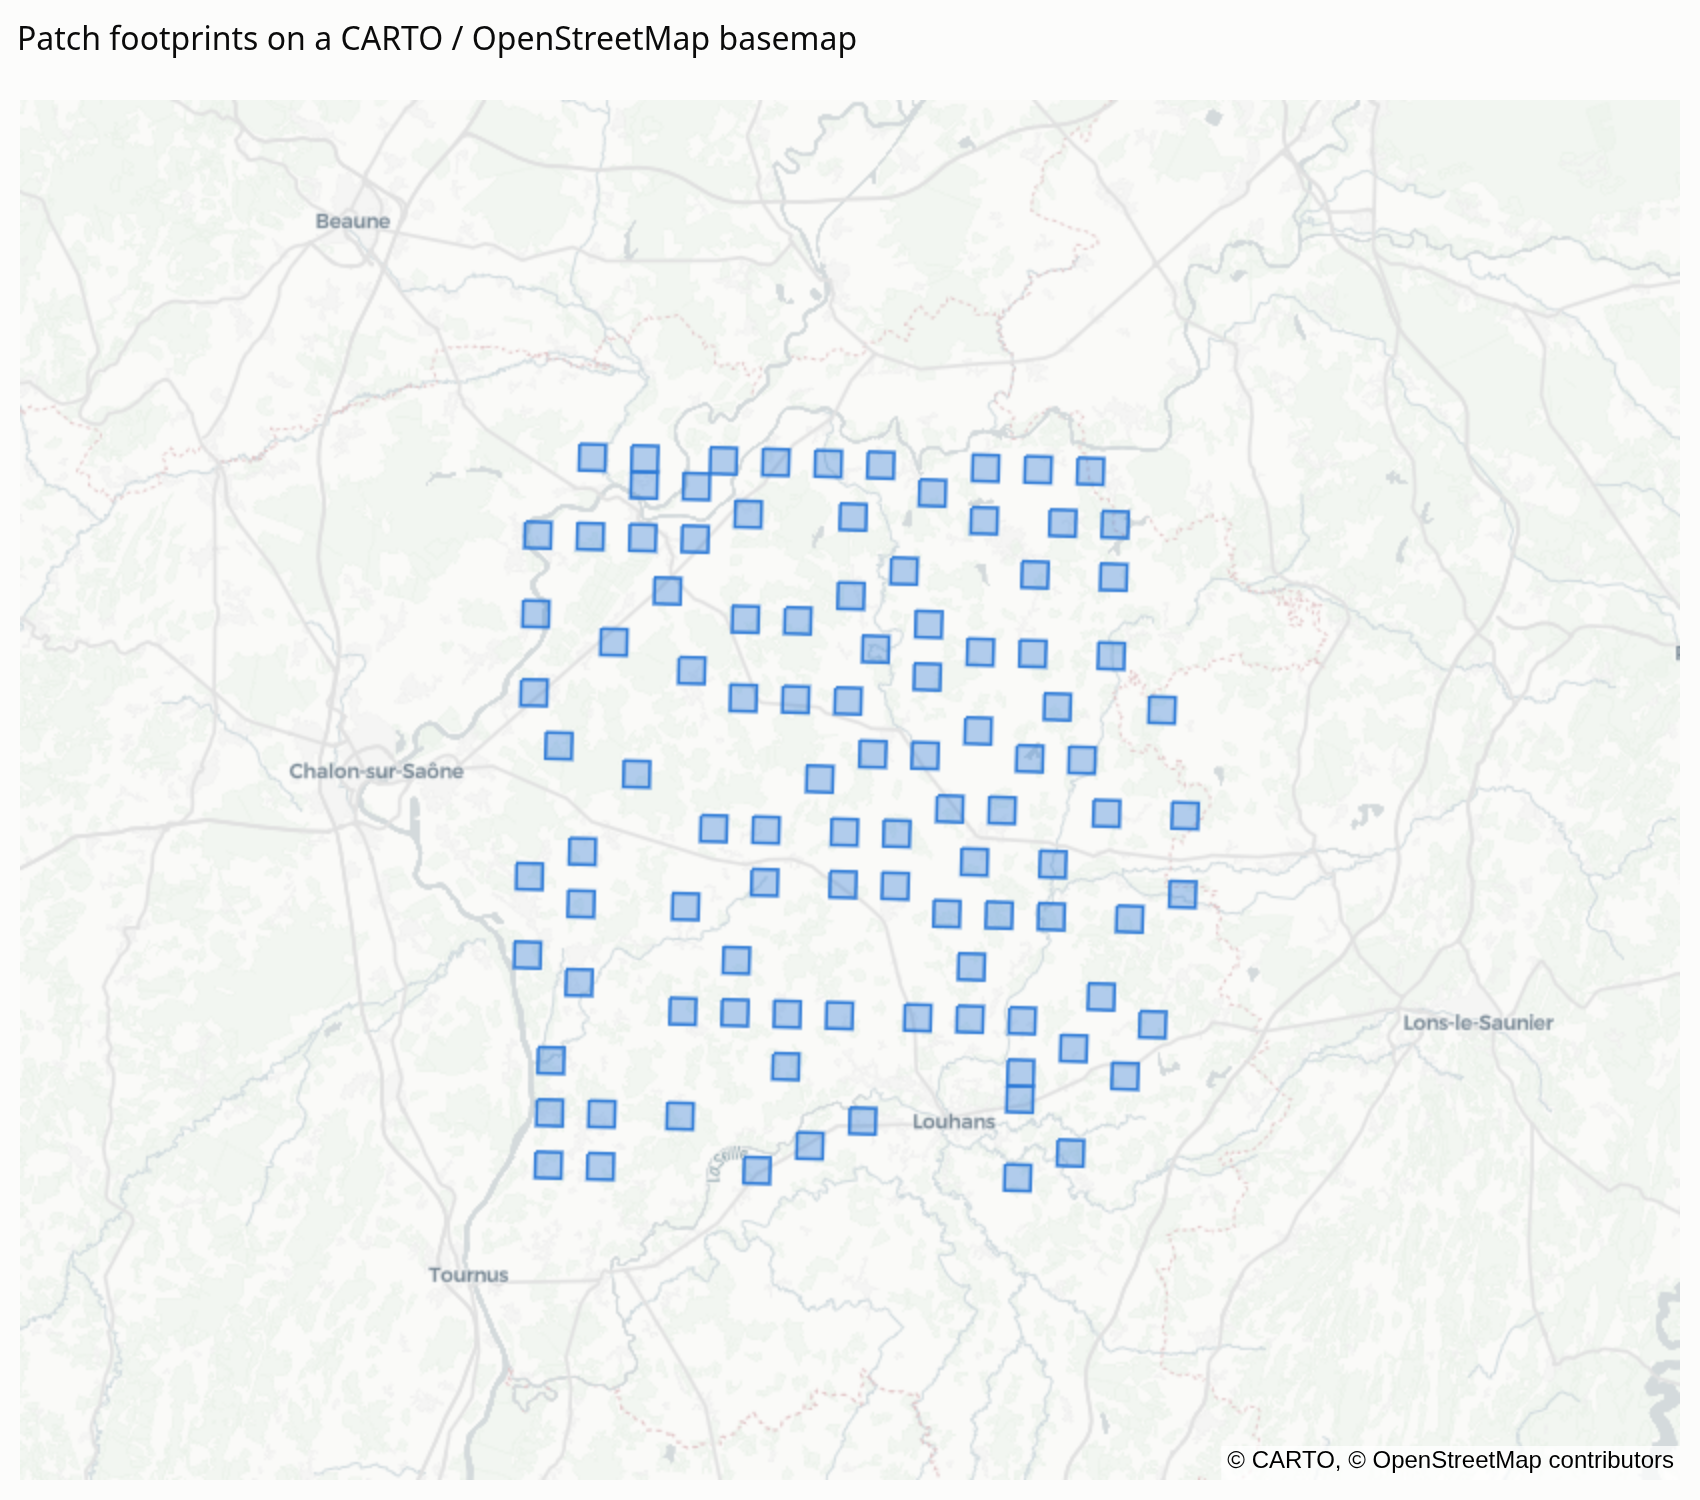

Distance from each patch to its nearest neighbouring patch (m):
count     102.0
mean     1275.0
std       416.0
min         0.0
25%      1279.0
50%      1279.0
75%      1279.0
max      2558.0


In [23]:
def polygon_coords(geometries):
    lon, lat = [], []
    for geom in geometries:
        x, y = geom.exterior.xy
        lon += [*x, None]
        lat += [*y, None]
    return lon, lat

centroids = gdf.geometry.centroid.to_crs('EPSG:4326')
lon, lat = polygon_coords(gdf_wgs84.geometry)
fig = go.Figure([
    go.Scattermap(lon=lon, lat=lat, mode='lines', fill='toself', fillcolor=with_alpha(SERIES[0], 0.35),
                  line=dict(color=SERIES[0], width=1.5), hoverinfo='skip'),
    go.Scattermap(lon=centroids.x, lat=centroids.y, mode='markers', marker=dict(size=16, opacity=0),
                  customdata=np.stack([gdf['ID_PATCH'], gdf['Fold'], gdf['N_Parcel']], axis=1),
                  hovertemplate='Patch %{customdata[0]}<br>Fold %{customdata[1]}<br>%{customdata[2]} parcels<extra></extra>'),
])
fig.update_layout(
    title='Patch footprints on a CARTO / OpenStreetMap basemap',
    map=dict(style='carto-positron', zoom=9.1,
             center=dict(lon=float(centroids.x.mean()), lat=float(centroids.y.mean()))),
    showlegend=False, width=850, height=750, margin=dict(l=10, r=10, t=50, b=10),
)
fig.write_image(f'{FIG_DIR}/aoi_basemap.png', scale=2)
# Map tiles are fetched from the web, which VS Code's notebook renderer blocks; show the exported image
display(StaticImage(filename=f'{FIG_DIR}/aoi_basemap.png', width=850))

geoms = gpd.GeoSeries(gdf.geometry.values, index=gdf['ID_PATCH'].values, crs=gdf.crs)
nn_dist = pd.Series({pid: geoms.drop(pid).distance(g).min() for pid, g in geoms.items()})
print('Distance from each patch to its nearest neighbouring patch (m):')
print(nn_dist.describe().round(0).to_string())

**Observations:**
- **Location:** east-central France, in the Bresse plain east of the Saône river, between Chalon-sur-Saône (west),
  Louhans (south) and Lons-le-Saunier (east). That is mostly Saône-et-Loire, with the eastern edge in Jura
  (Bourgogne-Franche-Comté). The bounding box is ~33 × 36 km (4.94–5.38 °E, 46.60–46.93 °N) inside one Sentinel-2 tile
  (T31TFM); the metadata geometries are in EPSG:2154 (Lambert-93).
- The 102 patches (1.28 × 1.28 km each) are a **sparse sample, not a wall-to-wall mosaic**: the median gap to the
  nearest other patch is exactly one patch width (1,279 m), and only three pairs of patches touch.
- The five `Fold` groups are spatially interleaved across the AOI (map in Section 9), and each touching pair lies within
  a single fold. This underpins the leakage-aware split in Task C.

## 8. Notes on the agricultural landscape

Based on the class list and observed distribution:

In [24]:
print("Classes observed in this subset (pixel_count > 0):")
print(class_df[class_df['pixel_count'] > 0][['class_id', 'class_name', 'pixel_pct', 'n_patches_present']].to_string(index=False))


Classes observed in this subset (pixel_count > 0):
 class_id                  class_name  pixel_pct  n_patches_present
        0                  Background  30.286662                102
        1                      Meadow  17.746630                101
        2           Soft winter wheat  11.914302                 95
        3                        Corn  11.770450                 98
       19                  Void label   8.621934                102
       15                    Soybeans   7.273955                 80
        5             Winter rapeseed   5.559704                 65
        4               Winter barley   3.433587                 64
       10            Winter triticale   0.910441                 25
       14           Leguminous fodder   0.755998                 27
        7                   Sunflower   0.573192                 18
       17                Mixed cereal   0.312356                 13
       18                     Sorghum   0.302004                 

### 8b. Crop phenology: NDVI time series per class

Median NDVI of the sampled pixels on each acquisition date, grouped by crop calendar (classes present in only 1–3
patches are left out). Grey bands mark dates where more than half of the AOI is flagged bright (Section 3b): all
curves dip together there because clouds, not crops, drive NDVI down.

In [25]:
PHENOLOGY_GROUPS = {
    'Winter crops (sown in autumn)': [2, 4, 5, 10],
    'Summer crops (sown in spring)': [3, 15, 7, 18],
    'Grassland, fodder and background': [1, 14, 0],
    'Spring and minor crops': [6, 17, 12],
}
fig = make_subplots(rows=len(PHENOLOGY_GROUPS), cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=list(PHENOLOGY_GROUPS))
for row, class_ids in enumerate(PHENOLOGY_GROUPS.values(), start=1):
    legend = 'legend' if row == 1 else f'legend{row}'
    for slot, cid in enumerate(class_ids):
        fig.add_trace(go.Scatter(
            x=acq_dates, y=np.median(ndvi_samples[cid], axis=0), mode='lines',
            name=f'{CLASS_NAMES[cid]} (n={len(ndvi_samples[cid]):,})', legend=legend,
            line=dict(color=SERIES[slot], width=2),
            hovertemplate=f'{CLASS_NAMES[cid]}<br>%{{x|%d %b %Y}}: NDVI %{{y:.2f}}<extra></extra>',
        ), row=row, col=1)
    domain = fig.layout[f'yaxis{"" if row == 1 else row}'].domain
    fig.layout[legend] = dict(x=1.01, xanchor='left', y=sum(domain) / 2, yanchor='middle')
for t in np.flatnonzero(cloudy_dates_mask):
    fig.add_vrect(x0=acq_dates[t] - pd.Timedelta(days=2), x1=acq_dates[t] + pd.Timedelta(days=2),
                  fillcolor=GRIDLINE, opacity=0.9, line_width=0, layer='below', row='all', col=1)
fig.update_yaxes(title_text='NDVI', range=[0, 1])
fig.update_layout(title='Median NDVI per class through the Sept 2018 – Oct 2019 season',
                  height=240 * len(PHENOLOGY_GROUPS), width=1200, margin=dict(r=280))
fig.write_image(f'{FIG_DIR}/ndvi_phenology_by_class.png', scale=2)
fig.show()

**Observations: the crop calendar is clearly visible**
- **Winter cereals** (wheat, barley, triticale) emerge in November, green up from March, peak at NDVI ≈ 0.9 in
  April–June and collapse at the late-June/July harvest. **Winter barley ripens first**: its NDVI is ~0.45 in mid-June
  while wheat is still ~0.85, its main cue against wheat and triticale. Wheat and triticale curves are almost identical,
  so confusion between them is expected.
- **Winter rapeseed** is established earliest (NDVI 0.4–0.8 already in Oct–Dec, when cereals are at 0.2–0.5). It also
  drops below the cereals on the early-May date (0.52 vs ~0.65), consistent with flowering, although that date looks
  hazy for every class.
- **Summer crops** stay at bare-soil NDVI (~0.2–0.3) until June. Sunflower peaks first (early July), soybean and corn
  in August, and corn stays green longest (≈ 0.9 in early September). Sorghum (7 patches only) is noisier and unusually
  green in spring, possibly a preceding cover or fodder crop.
- **Meadow, leguminous fodder and background** are green all year. Background (woods, hedges, gardens) looks much like
  grassland in NDVI, a likely confusion source.
- **Spring barley** stays low until April and peaks in May–June; mixed cereal behaves like a winter cereal.
- Shaded cloudy dates pull every class to ~0 at once. Smaller simultaneous dips (e.g. early July) point to partial haze
  that the brightness proxy misses.
- **Implication for modelling:** classes differ in *when* they green up and senesce, so the natural input is a per-date
  feature vector over the whole season, rather than a single date or annual statistics.

### 8c. Parcel structure

`N_Parcel` and `Parcel_Cover` in the metadata give the number of annotated parcels in a patch and the fraction of the
patch they cover. A patch is 128 × 128 px at 10 m = 163.84 ha, so mean parcel size ≈ Parcel_Cover × 163.84 ha / N_Parcel.

In [26]:
PATCH_AREA_HA = 128 * 128 * 10 * 10 / 10_000
meta = ds.metadata.set_index('ID_PATCH')
parcel_df = pd.DataFrame({
    'n_parcels': meta['N_Parcel'],
    'parcel_cover_pct': 100 * meta['Parcel_Cover'],
    'non_background_pct': 100 * (1 - counts[0] / counts.sum(axis=1)),
    'crop_label_pct': 100 * counts.drop(columns=[0, 19]).sum(axis=1) / counts.sum(axis=1),
})
parcel_df['mean_parcel_ha'] = parcel_df['parcel_cover_pct'] / 100 * PATCH_AREA_HA / parcel_df['n_parcels']
print('Correlation of Parcel_Cover with the non-background share of the label map (void included): '
      f"{parcel_df['parcel_cover_pct'].corr(parcel_df['non_background_pct']):.3f}")
print('Correlation of Parcel_Cover with the crop-label share (void excluded): '
      f"{parcel_df['parcel_cover_pct'].corr(parcel_df['crop_label_pct']):.3f}")

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.1,
                    subplot_titles=['Annotated parcels per patch', 'Mean parcel size per patch'])
for col, column in enumerate(['n_parcels', 'mean_parcel_ha'], start=1):
    fig.add_trace(go.Histogram(x=parcel_df[column], nbinsx=20,
                               marker=dict(color=SERIES[0], line=dict(color=SURFACE, width=2))), row=1, col=col)
fig.update_xaxes(title_text='Parcels in the patch', row=1, col=1)
fig.update_xaxes(title_text='Mean parcel size (ha)', row=1, col=2)
fig.update_yaxes(title_text='Number of patches', row=1, col=1)
fig.update_layout(title='Parcel structure of the 102 patches', showlegend=False, width=1050, height=420, bargap=0)
fig.write_image(f'{FIG_DIR}/parcel_structure.png', scale=2)
fig.show()
parcel_df.describe().round(2)

Correlation of Parcel_Cover with the non-background share of the label map (void included): 0.998
Correlation of Parcel_Cover with the crop-label share (void excluded): 0.947


,n_parcels,parcel_cover_pct,non_background_pct,crop_label_pct,mean_parcel_ha
count,102.00,102.00,102.00,102.00,102.00
mean,49.33,70.50,69.71,61.09,2.44
std,12.69,14.15,14.03,13.30,0.62
min,21.00,33.30,33.32,24.69,1.09
25%,41.00,63.08,62.48,54.83,1.99
50%,48.00,71.33,69.90,61.00,2.38
75%,57.00,80.12,79.77,69.44,2.85
max,82.00,94.11,93.87,85.52,4.27


**Observations:**
- Patches hold **49 annotated parcels on average** (21–82), with a mean parcel size of **2.4 ha** (1.1–4.3 ha). These
  are small fields: a 2.4 ha field is only ~240 Sentinel-2 pixels, and about a quarter of them lie on the field edge,
  where a 10 m pixel mixes the crop with hedges, margins or the neighbouring field. Mixed edge pixels will be a
  significant error source for any pixel classifier.
- `Parcel_Cover` matches the non-background share of the label map almost exactly (r = 0.998 with void included vs
  0.947 without). So **void pixels belong to annotated parcels** (parcels or parts of parcels without a reliable label),
  not to the background. This supports excluding void from training and scoring rather than merging it into Background.
- Annotated parcels cover ~70 % of an average patch (33–94 %). The rest is background: woods, hedges, villages, roads,
  water.

### 8d. What the data says about the agricultural landscape

- **Mixed livestock–arable farming.** Meadow is the largest agricultural class (17.7 % of pixels, present in 101 of 102
  patches), followed by soft winter wheat (11.9 %), corn (11.8 %), soybeans (7.3 %), winter rapeseed (5.6 %) and winter
  barley (3.4 %). Extensive grassland plus maize is typical of livestock areas such as the Bresse, known for poultry
  and dairy.
- **A small-field, hedged landscape:** mean parcel ≈ 2.4 ha, and ~30 % of each patch is non-agricultural background
  (woodland, hedgerows, villages), clearly visible in the imagery.
- **Two main crop calendars** (Section 8b): autumn-sown cereals and rapeseed (peak April–June, harvest late June–July)
  and spring-sown summer crops (peak July–September). The single season is fully covered (46 shared dates,
  Sep 2018 – Oct 2019) but unevenly clean: 28 clear dates and 5 heavily clouded ones, including early June and
  mid-August.
- **A long tail of minor crops.** Grapevine, potatoes and orchard each occur in a single patch, durum wheat in three,
  and beet nowhere. These classes cannot be learned or evaluated reliably from this subset.
- *The regional context comes from the basemap and general agronomic knowledge, not from external statistics.*

## 9. Train / validation / test split (Task C)

**Strategy: whole patches, taken from the official PASTIS folds.**

- **The unit is the patch, not the pixel.** Neighbouring pixels, and all pixels of one parcel, are near-duplicates. A
  random pixel split would put near-identical samples in train and test and badly overstate accuracy. Assigning whole
  patches keeps every parcel in exactly one split.
- **Official folds.** `metadata.geojson` carries the PASTIS `Fold` (1–5) assignment made by the dataset authors. Using
  three folds for training, one for validation and one for test follows the PASTIS benchmark protocol and makes the
  split reproducible and comparable.
- **Which folds become validation and test?** All 20 ordered (val, test) pairs are scored with an explicit rule
  (`src/splits.py::choose_fold_pair`): (1) maximise the number of classes present in training, because a pixel
  classifier can never predict a class it has not seen; (2) maximise the number of classes present in *both* val and
  test; (3) minimise the Jensen–Shannon divergence between the val/test class distributions and the overall one.
- The chosen folds are pinned in `configs/config.yaml`; `python -m src.splits` writes the patch IDs to
  `splits/train_ids.txt`, `splits/val_ids.txt` and `splits/test_ids.txt`.

In [27]:
from src.config import load_config
from src.splits import (SPLIT_NAMES, assign_splits, choose_fold_pair, nearest_train_distance,
                        save_split, score_fold_pairs, split_class_totals)

cfg = load_config()
folds = ds.metadata.set_index('ID_PATCH')['Fold']
fold_scores = score_fold_pairs(counts, folds, ignore_index=19)
best_val, best_test = choose_fold_pair(fold_scores)
val_fold, test_fold = cfg['split']['val_fold'], cfg['split']['test_fold']
print(f'Rule selects validation = fold {best_val}, test = fold {best_test}; '
      f'config uses validation = fold {val_fold}, test = fold {test_fold}.')
columns = ['val_fold', 'test_fold', 'n_patches_train', 'n_classes_train', 'n_classes_val', 'n_classes_test',
           'jsd_val', 'jsd_test']
fold_scores.sort_values(['n_classes_train', 'min_classes_val_test', 'jsd_val_plus_test'],
                        ascending=[False, False, True])[columns].head(8).round(3)

Rule selects validation = fold 4, test = fold 5; config uses validation = fold 4, test = fold 5.


,val_fold,test_fold,n_patches_train,n_classes_train,n_classes_val,n_classes_test,jsd_val,jsd_test
15,4,5,66,18,14,15,0.099,0.083
19,5,4,66,18,15,14,0.083,0.099
11,3,5,61,18,14,15,0.125,0.083
18,5,3,61,18,15,14,0.083,0.125
10,3,4,61,18,14,14,0.125,0.099
14,4,3,61,18,14,14,0.099,0.125
3,1,5,64,17,15,15,0.089,0.083
16,5,1,64,17,15,15,0.083,0.089


In [28]:
assignment = assign_splits(folds, val_fold, test_fold)
split_paths = save_split(assignment, cfg['paths']['splits_dir'])
class_totals = split_class_totals(counts, assignment, ignore_index=19)
split_summary = pd.DataFrame({
    'folds': [', '.join(map(str, sorted(folds[assignment == s].unique()))) for s in SPLIT_NAMES],
    'patches': [int((assignment == s).sum()) for s in SPLIT_NAMES],
    'labelled_pixels': class_totals.sum().values,
    'classes_present': (class_totals > 0).sum().values,
}, index=list(SPLIT_NAMES))
split_summary['pixel_share_pct'] = (100 * split_summary['labelled_pixels'] / split_summary['labelled_pixels'].sum()).round(1)
for name, path in split_paths.items():
    print(f'{name:5s} -> {path.relative_to(cfg["paths"]["splits_dir"].parent)}')
split_summary

train -> splits/train_ids.txt
val   -> splits/val_ids.txt
test  -> splits/test_ids.txt


,folds,patches,labelled_pixels,classes_present,pixel_share_pct
train,"1, 2, 3",66,987951,18,64.7
val,4,18,267316,14,17.5
test,5,18,271814,15,17.8


In [29]:
presence = (counts.drop(columns=19) > 0).groupby(assignment).sum().T[list(SPLIT_NAMES)]
presence.index = [CLASS_NAMES[c] for c in presence.index]
share = 100 * class_totals / class_totals.sum()
share.index = [CLASS_NAMES[c] for c in share.index]
keep = class_totals.sum(axis=1).values > 0
share, presence = share[keep].sort_values('train'), presence[keep]

fig = go.Figure([
    go.Scatter(x=share[name].where(share[name] > 0), y=share.index, mode='markers', name=name.capitalize(),
               marker=dict(color=SERIES[k], size=10, line=dict(color=SURFACE, width=2)),
               customdata=presence.loc[share.index, name],
               hovertemplate='%{y}<br>%{x:.3f}% of pixels, in %{customdata} patches<extra>' + name + '</extra>')
    for k, name in enumerate(SPLIT_NAMES)
])
fig.update_xaxes(type='log', title_text='Share of the split’s labelled pixels (%, log scale)')
fig.update_layout(title='Class distribution per split (missing marker = class absent from that split)',
                  height=620, width=950, legend=dict(orientation='h', x=0, y=1.02, yanchor='bottom'))
fig.write_image(f'{FIG_DIR}/split_class_distribution.png', scale=2)
fig.show()
presence.rename(columns=lambda s: f'patches_{s}')

Fold,patches_train,patches_val,patches_test
Background,66,18,18
Meadow,65,18,18
Soft winter wheat,60,18,17
Corn,64,18,16
Winter barley,42,11,11
Winter rapeseed,38,14,13
Spring barley,5,3,1
Sunflower,8,4,6
Grapevine,1,0,0
Winter triticale,18,3,4


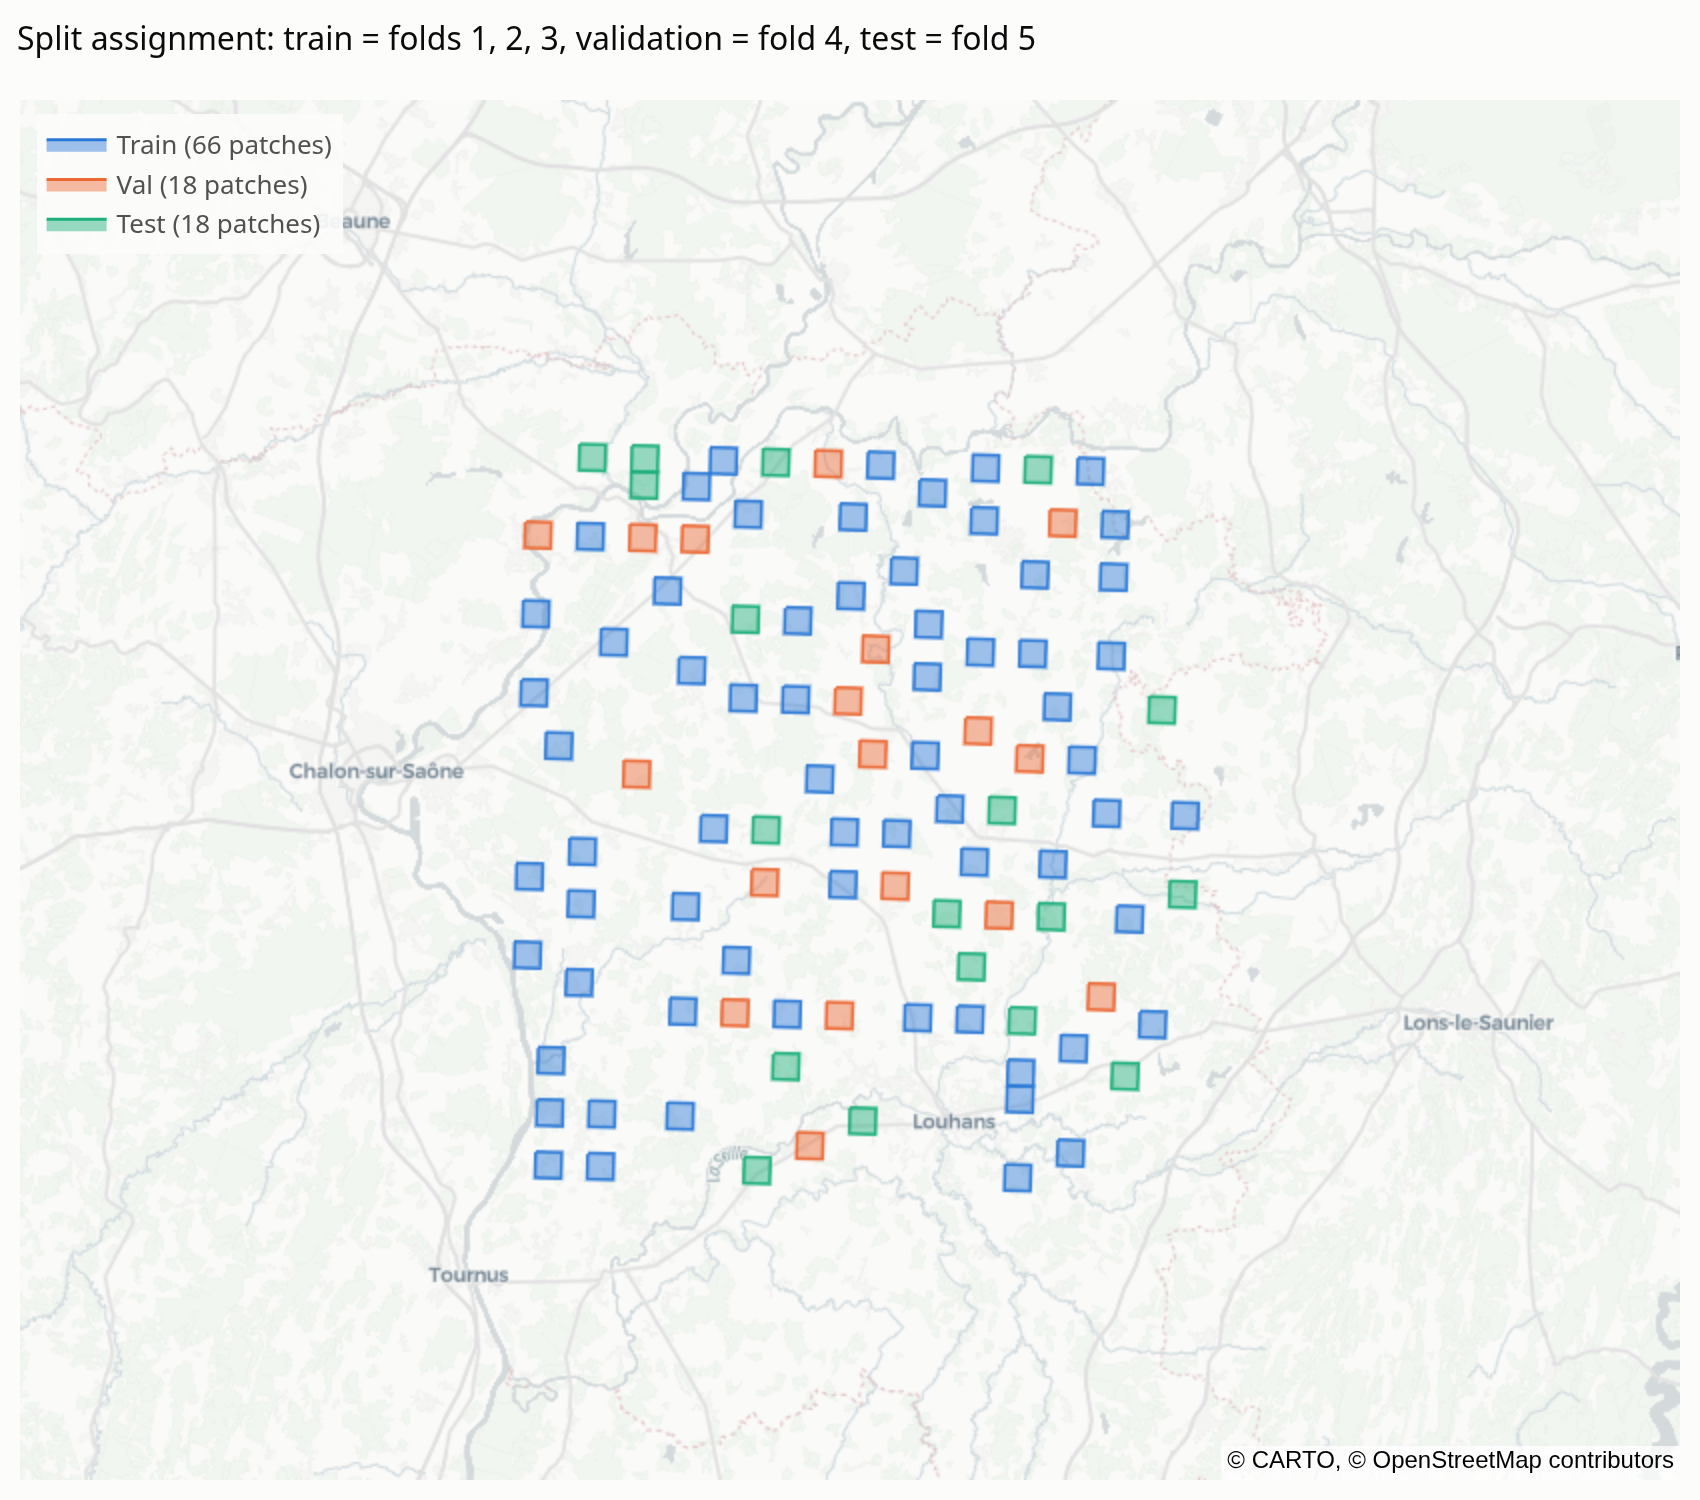

Distance from each validation / test patch to the nearest training patch (m):
      count     min     50%     max
Fold                               
test   18.0  1279.0  1279.0  4044.0
val    18.0  1279.0  1279.0  5116.0
Held-out patches touching a training patch: 0 of 36


In [30]:
fig = go.Figure()
for k, name in enumerate(SPLIT_NAMES):
    in_split = gdf['ID_PATCH'].map(assignment).values == name
    lon, lat = polygon_coords(gdf_wgs84.geometry[in_split])
    fig.add_trace(go.Scattermap(lon=lon, lat=lat, mode='lines', fill='toself', fillcolor=with_alpha(SERIES[k], 0.45),
                                line=dict(color=SERIES[k], width=1.5), hoverinfo='skip',
                                name=f'{name.capitalize()} ({in_split.sum()} patches)'))
fig.update_layout(
    title=f"Split assignment: train = folds {split_summary.loc['train', 'folds']}, validation = fold {val_fold}, test = fold {test_fold}",
    map=dict(style='carto-positron', zoom=9.1,
             center=dict(lon=float(centroids.x.mean()), lat=float(centroids.y.mean()))),
    legend=dict(x=0.01, y=0.99, bgcolor=with_alpha('#fcfcfb', 0.9)),
    width=850, height=750, margin=dict(l=10, r=10, t=50, b=10),
)
fig.write_image(f'{FIG_DIR}/split_map.png', scale=2)
# Map tiles are fetched from the web, which VS Code's notebook renderer blocks; show the exported image
display(StaticImage(filename=f'{FIG_DIR}/split_map.png', width=850))

dist_to_train = nearest_train_distance(geoms, assignment)
print('Distance from each validation / test patch to the nearest training patch (m):')
print(dist_to_train.groupby(assignment[dist_to_train.index]).describe()[['count', 'min', '50%', 'max']].round(0))
print(f'Held-out patches touching a training patch: {(dist_to_train < 1).sum()} of {len(dist_to_train)}')

**Observations and implications of the split:**
- Train / val / test = **66 / 18 / 18 patches** (folds 1–3 / 4 / 5), i.e. 64.7 / 17.5 / 17.8 % of labelled pixels. The
  rule's winner is the conventional PASTIS arrangement. The mirrored pair (val = 5, test = 4) ties on every criterion,
  and the tie is broken by enumeration order.
- Training sees **18 of the 19 non-void classes**; Beet is absent from the whole subset. Validation has 14 classes,
  test 15.
- **A class in only one patch cannot be both learned and evaluated.** Grapevine, potatoes and orchard exist only in
  training (one patch each), so their held-out performance is unmeasurable. Sorghum is absent from validation. Spring
  barley, durum wheat and fruits/vegetables appear in only 1–3 held-out patches, so their held-out scores will be very
  noisy.
- **Spatial leakage is controlled, not eliminated.** No held-out patch touches a training patch (the nearest is
  ≥ 1.28 km away, one patch width), so no parcel is shared across splits. But the folds are interleaved over one
  33 × 36 km area with shared weather, soils and farming practices. The test score therefore measures *within-region*
  generalisation and likely overestimates performance on another region or year.
- The major classes have similar proportions across splits (dot plot). Validation has somewhat more wheat (~18 % vs
  12 %) and less soybean (~6 % vs 9 %) than training.

## 10. Model training (Task D)

### Approach: pixel-level classification of the full Sentinel-2 time series

Each labelled pixel is one sample, and its features are its complete time series. Why this formulation:
- The labels are a semantic layer only (no parcel instance IDs), so per-pixel classification is the direct way to
  produce a segmentation map. Parcel-level classification would need instance boundaries.
- Section 8b shows the classes differ mainly in *timing* (green-up, peak, harvest), so every date is kept as a feature.
  This is possible without temporal resampling because all 102 patches share the same 46 acquisition dates.
- Tabular models on ~550 features train in minutes on a CPU. The development machine has 8 cores, no GPU and only
  ~1.3 GB of free RAM, so deep segmentation models were out of scope.

| Aspect | Choice |
|---|---|
| **Input features (552 per pixel)** | 10 bands × 46 dates of surface reflectance + NDVI × 46 + NDMI × 46 (`src/preprocessing.py`) |
| **Preprocessing** | DN / 10,000, clipped to [0, 1]; void pixels (19) dropped; standardisation (and PCA for the SVM) fitted on training data only, inside each model pipeline |
| **Training sample** | Class-capped random sample: at most 15,000 pixels per class, drawn uniformly from all 66 training patches (seed 42). Rare classes are kept in full. The SVM uses a further 5,000-per-class cap because its cost grows quadratically. |
| **Class imbalance** | (1) the per-class cap (Background: 327k → 15k pixels); (2) sample weights ∝ class frequency<sup>−0.5</sup>, normalised to mean 1: the rarest class (Orchard, 75 px) gets ~14× the weight of a capped class, without the extreme weights of full balancing that would overfit single-patch classes; (3) models compared on macro-F1 and mIoU, not only overall accuracy |
| **Model selection** | Validation data only: GBDT early stopping on classification error (see below for why not log-loss) and small grid searches for logistic regression, the SVM and LightGBM (macro-F1), both on a class-capped validation subsample (≤ 3,000 px per class). The random forest uses fixed, memory-bounded settings. **The test split is not used here.** |
| **Reproduce** | `python -m src.splits` then `python -m src.train` (settings in `configs/config.yaml`; ≈ 36 min on 8 CPU cores) |

**Why sample pixels at all?** The training patches contain ~1.0 M labelled pixels, but pixels inside one parcel are
near-duplicates, and a full matrix would be ~2.2 GB of float32 features. The capped sample (141,831 pixels, 313 MB)
keeps every parcel represented, removes most redundancy and bounds memory.

In [31]:
LOG = json.load(open(f'{METRICS_DIR}/training_log.json'))
sample_info = LOG['training_sample']
available = class_totals['train'].rename(index=CLASS_NAMES)
sample_df = pd.DataFrame({
    'pixels_in_train_patches': available,
    'pixels_sampled': pd.Series(sample_info['class_counts']),
    'sample_weight': pd.Series(sample_info['class_weights']),
}).dropna(subset=['pixels_sampled']).astype({'pixels_sampled': int})
sample_df['sampled_%'] = (100 * sample_df['pixels_sampled'] / sample_df['pixels_in_train_patches']).round(1)
print(f"Training sample: {sample_info['n_pixels']:,} pixels × {sample_info['n_features']} features "
      f"(from {int(available.sum()):,} labelled training pixels). "
      f"Validation subsample for early stopping / tuning: {sample_info['early_stopping_pixels']:,} pixels.")
sample_df.sort_values('pixels_in_train_patches', ascending=False)

Training sample: 141,831 pixels × 552 features (from 987,951 labelled training pixels). Validation subsample for early stopping / tuning: 29,747 pixels.


,pixels_in_train_patches,pixels_sampled,sample_weight,sampled_%
Background,327573,14743,0.8376,4.5
Meadow,198324,14855,0.8344,7.5
Corn,127407,14987,0.8307,11.8
Soft winter wheat,114971,15064,0.8286,13.1
Soybeans,91773,15020,0.8298,16.4
Winter rapeseed,56030,15122,0.8270,27.0
Winter barley,34871,15038,0.8293,43.1
Winter triticale,10335,10335,1.0004,100.0
Leguminous fodder,8892,8892,1.0785,100.0
Sunflower,4607,4607,1.4984,100.0


### Models and hyperparameters

Six classifiers, from a trivial baseline to gradient boosting. All hyperparameters live in `configs/config.yaml`.

| Model | Family | Configuration (grid in brackets) |
|---|---|---|
| Majority class | baseline | always predicts the most frequent training class (Background) |
| Logistic regression | linear | standardise → multinomial L2 logistic regression, C ∈ {0.01, 0.1, 1} |
| SVM (RBF) | kernel | standardise → PCA(48) → RBF SVC, C ∈ {0.3, 1, 3} × γ ∈ {0.0003, 0.001, 0.003}, ≤ 5,000 px/class |
| Random forest | bagged trees | 200 trees, √F features per split, min 5 samples per leaf |
| XGBoost | gradient boosting | depth 6, learning rate 0.1, row / column subsampling 0.8 / 0.5, ≤ 600 rounds, early stopping after 40 rounds without improvement in validation error |
| LightGBM | gradient boosting | leaves ∈ {15, 63} × min samples per leaf ∈ {20, 200}, learning rate 0.1, row / column subsampling 0.8 / 0.5, L2 = 1, ≤ 1,500 rounds, early stopping after 50 rounds without improvement in validation error |

The SVM grid was re-centred after a first one peaked at its corner (C = 1, γ = 0.001, the smoothest model tried), so
the chosen values are now bracketed. XGBoost keeps a single configuration at ~8 min per fit. Forest size is bounded by
memory rather than tuned: a tree on this sample costs ~1.4 MB of RAM. LightGBM uses learning rate 0.1 rather than 0.05
to bound CPU time, since early stopping lets it run for many more rounds.

In [32]:
MODEL_LABELS = {
    'majority': 'Majority class', 'logistic_regression': 'Logistic regression', 'svm_rbf': 'SVM (RBF)',
    'random_forest': 'Random forest', 'xgboost': 'XGBoost', 'lightgbm': 'LightGBM',
}
search = pd.read_csv(f'{METRICS_DIR}/hyperparameter_search.csv')
grid_columns = [c for c in search.columns if c not in ('model', 'val_subsample_macro_f1', 'fit_seconds')]
best_grid = search.loc[search.groupby('model')['val_subsample_macro_f1'].idxmax()].set_index('model')

def format_params(params):
    return ', '.join(f'{k}={v:g}' if isinstance(v, float) else f'{k}={v}' for k, v in params.items()) or '—'

details = []
for name, info in LOG['models'].items():
    chosen = best_grid.loc[name, grid_columns].dropna().to_dict() if name in best_grid.index else {}
    row = {'model': name,
           'fixed_params': format_params({k: v for k, v in info['params'].items() if k != 'search'}),
           'grid_selected': format_params(chosen)}
    for key in ('n_boosting_rounds', 'n_support_vectors', 'n_iter', 'pca_explained_variance'):
        if key in info:
            row[key] = info[key]
    row.update(fit_s=info['fit_seconds'], grid_search_s=info.get('search_seconds', 0.0),
               predict_val_s=info['predict_seconds'])
    details.append(row)
pd.DataFrame(details).set_index('model')

,fixed_params,grid_selected,fit_s,grid_search_s,predict_val_s,n_iter,n_support_vectors,pca_explained_variance,n_boosting_rounds
model,,,,,,,,,
majority,—,—,0.0,0.0,0.0,NaN,NaN,NaN,NaN
logistic_regression,max_iter=2000,C=0.1,69.7,227.8,1.0,238.0,NaN,NaN,NaN
svm_rbf,"max_pixels_per_class=5000, pca_components=48","C=1, gamma=0.0003",23.9,461.6,376.3,NaN,21241.0,0.925182,NaN
random_forest,"n_estimators=200, max_features=sqrt, min_sampl...",—,124.6,0.0,10.7,NaN,NaN,NaN,NaN
xgboost,"n_estimators=600, learning_rate=0.1, max_depth...",—,512.8,0.0,1.8,NaN,NaN,NaN,93.0
lightgbm,"n_estimators=1500, learning_rate=0.1, metric=[...","num_leaves=15, min_child_samples=200",63.3,309.9,1.6,NaN,NaN,NaN,46.0


In [33]:
for name, group in search.groupby('model', sort=False):
    params = [c for c in grid_columns if group[c].notna().any()]
    table = group[params + ['val_subsample_macro_f1', 'fit_seconds']].sort_values('val_subsample_macro_f1', ascending=False)
    print(f'--- {MODEL_LABELS.get(name, name)}: grid scored by macro-F1 on the validation subsample ---')
    print(table.to_string(index=False), end='\n\n')

--- Logistic regression: grid scored by macro-F1 on the validation subsample ---
   C  val_subsample_macro_f1  fit_seconds
0.10                  0.6423         69.7
1.00                  0.6411         98.6
0.01                  0.6368         59.2

--- SVM (RBF): grid scored by macro-F1 on the validation subsample ---
  C  gamma  val_subsample_macro_f1  fit_seconds
1.0 0.0003                  0.6213         23.9
0.3 0.0003                  0.6168         36.3
3.0 0.0003                  0.6096         15.9
0.3 0.0010                  0.6021         24.1
1.0 0.0010                  0.5632         16.3
3.0 0.0010                  0.5188         12.3
0.3 0.0030                  0.4898         22.9
3.0 0.0030                  0.4863         14.4
1.0 0.0030                  0.4853         16.0

--- LightGBM: grid scored by macro-F1 on the validation subsample ---
 num_leaves  min_child_samples  val_subsample_macro_f1  fit_seconds
       15.0              200.0                  0.6202      

### Early stopping, and how quickly the boosting models saturate

A first run stopped both boosting models on validation log-loss: XGBoost after 54 rounds and LightGBM (63 leaves,
learning rate 0.05) after 48. Both landed below the random forest on validation mIoU, at 0.548 and 0.540 against
0.577. The final models stop on classification error instead, and the curves below come from those fits.
- **Log-loss turns up before error does.** For XGBoost, log-loss is lowest at round 54 and then climbs, while error
  keeps improving slowly until round 93; for LightGBM the two minima are at rounds 33 and 46. Log-loss punishes
  confident mistakes, and the validation subsample contains classes that no model gets right (mixed cereal, durum
  wheat, fruits/vegetables: F1 = 0 for every model). So the loss on those pixels grows as boosting sharpens its
  probabilities. Stopping on error raised XGBoost from 0.548 to 0.559 mIoU.
- **Either way, both models saturate early.** Validation error flattens after ~50–90 rounds, and LightGBM does better
  with *smaller* trees (15 leaves, ≥ 200 samples per leaf) than with 63 leaves. Extra capacity fits detail specific to
  the 66 training patches that does not transfer to unseen patches. Performance is limited by between-patch variation
  (different fields, soils, management and local clouds) rather than by model capacity.

In [34]:
fig = make_subplots(rows=2, cols=2, shared_xaxes='columns', vertical_spacing=0.12, horizontal_spacing=0.08,
                    subplot_titles=['XGBoost: validation error', 'LightGBM: validation error',
                                    'XGBoost: validation log-loss', 'LightGBM: validation log-loss'])
stopping_rows = []
for col, name in enumerate(['xgboost', 'lightgbm'], start=1):
    curve = pd.read_csv(f'{METRICS_DIR}/early_stopping_curve_{name}.csv')
    chosen = LOG['models'][name]['n_boosting_rounds']
    logloss_best = int(curve.loc[curve['logloss'].idxmin(), 'round'])
    axis_suffix = '' if col == 1 else str(col)
    for row, metric in enumerate(['error', 'logloss'], start=1):
        fig.add_trace(go.Scatter(x=curve['round'], y=curve[metric], mode='lines', line=dict(color=SERIES[0], width=2),
                                 hovertemplate=f'round %{{x}}: {metric} %{{y:.4f}}<extra></extra>'), row=row, col=col)
        fig.add_vline(x=logloss_best, line=dict(color=SERIES[1], width=1.5), row=row, col=col)
        fig.add_vline(x=chosen, line=dict(color=INK_MUTED, width=1.5), row=row, col=col)
    fig.add_annotation(x=logloss_best, y=1, yref=f'y{axis_suffix} domain', xref=f'x{axis_suffix}', text='log-loss minimum',
                       showarrow=False, xanchor='right', yanchor='top', font=dict(size=11, color=SERIES[1]))
    fig.add_annotation(x=chosen, y=1, yref=f'y{axis_suffix} domain', xref=f'x{axis_suffix}', text='stopped (error)',
                       showarrow=False, xanchor='left', yanchor='top', font=dict(size=11, color=INK_MUTED))
    at = lambda r: curve.loc[curve['round'] == r].iloc[0]
    stopping_rows.append({'model': MODEL_LABELS[name], 'logloss_minimum_round': logloss_best,
                          'error_at_logloss_minimum': at(logloss_best)['error'],
                          'rounds_used (error stopping)': chosen, 'error_at_rounds_used': at(chosen)['error'],
                          'logloss_at_rounds_used': at(chosen)['logloss']})
fig.update_xaxes(title_text='Boosting round', row=2)
fig.update_layout(title='Early-stopping curves on the validation subsample (one tree per class per round)',
                  showlegend=False, width=1150, height=620)
fig.write_image(f'{FIG_DIR}/early_stopping_curves.png', scale=2)
fig.show()
pd.DataFrame(stopping_rows).set_index('model').round(4)

,logloss_minimum_round,error_at_logloss_minimum,rounds_used (error stopping),error_at_rounds_used,logloss_at_rounds_used
model,,,,,
XGBoost,54,0.1828,93,0.1822,0.7069
LightGBM,33,0.1839,46,0.1819,0.7254


### Validation results

All numbers below are on the **full validation split** (18 patches, 267,316 labelled pixels, void excluded). Macro-F1
and mIoU average over the 14 classes present in validation, so they weight rare classes equally with common ones.

In [35]:
comparison = pd.read_csv(f'{METRICS_DIR}/val_model_comparison.csv').sort_values('miou', ascending=False)
comparison.insert(0, 'label', comparison['model'].map(MODEL_LABELS))
comparison[['label', 'overall_accuracy', 'macro_f1', 'miou', 'kappa', 'weighted_f1',
            'fit_seconds', 'predict_seconds', 'model_size_mb']].round(3).set_index('label')

,overall_accuracy,macro_f1,miou,kappa,weighted_f1,fit_seconds,predict_seconds,model_size_mb
label,,,,,,,,
Random forest,0.859,0.660,0.577,0.828,0.857,124.6,10.7,47.41
XGBoost,0.865,0.635,0.559,0.835,0.862,512.8,1.8,2.49
LightGBM,0.861,0.631,0.551,0.830,0.858,63.3,1.6,0.61
Logistic regression,0.850,0.635,0.547,0.818,0.851,69.7,1.0,0.05
SVM (RBF),0.818,0.596,0.499,0.780,0.821,23.9,376.3,5.01
Majority class,0.305,0.033,0.022,0.000,0.143,0.0,0.0,0.00


In [36]:
metrics = [('overall_accuracy', 'Overall accuracy'), ('macro_f1', 'Macro-F1'), ('miou', 'mIoU')]
order = comparison.sort_values('miou')
colors = [INK_MUTED if m == 'majority' else SERIES[0] for m in order['model']]
fig = make_subplots(rows=1, cols=3, shared_yaxes=True, horizontal_spacing=0.04,
                    subplot_titles=[title for _, title in metrics])
for col, (key, title) in enumerate(metrics, start=1):
    fig.add_trace(go.Bar(
        x=order[key], y=order['label'], orientation='h', marker_color=colors,
        text=order[key].map('{:.3f}'.format), textposition='outside', cliponaxis=False,
        hovertemplate='%{y}<br>' + title + ': %{x:.3f}<extra></extra>',
    ), row=1, col=col)
    fig.update_xaxes(range=[0, 1.12], showticklabels=False, showgrid=False, row=1, col=col)
fig.update_layout(title='Validation scores per model (grey = majority-class baseline)', showlegend=False,
                  width=1150, height=420, bargap=0.3)
fig.write_image(f'{FIG_DIR}/val_model_comparison.png', scale=2)
fig.show()

**How stable is this ranking?** Validation has only 18 patches, so the scores depend on which fields happen to be in
them. A patch-level bootstrap (1,000 resamples of the 18 validation patches, the same resamples for every model) gives
a 95 % interval for each model's mIoU, and how often the top model beats each of the others.

In [37]:
from src.evaluate import confusion_matrix, metrics_from_confusion

val_ids = [int(x) for x in (cfg['paths']['splits_dir'] / 'val_ids.txt').read_text().split()]
val_truth = np.stack([ds.load_target(pid)[0] for pid in val_ids])
patch_cms = {}
for name in comparison['model']:
    pred = np.load(f'../outputs/predictions/val_{name}.npy')
    patch_cms[name] = np.stack([confusion_matrix(t[t != 19], p[t != 19], 20) for t, p in zip(val_truth, pred)])

draws = np.random.default_rng(0).integers(0, len(val_ids), size=(1000, len(val_ids)))
boot = pd.DataFrame({name: [metrics_from_confusion(cms[d].sum(axis=0))[0]['miou'] for d in draws]
                     for name, cms in patch_cms.items()})
top = comparison.iloc[0]['model']
stability = pd.DataFrame({
    'label': comparison['label'].values,
    'miou': comparison['miou'].values,
    'ci_low': boot.quantile(0.025)[comparison['model']].values,
    'ci_high': boot.quantile(0.975)[comparison['model']].values,
    f'p_{top}_better': [(boot[top] > boot[m]).mean() if m != top else np.nan for m in comparison['model']],
}, index=comparison['model'])

shown = stability.drop(index='majority').iloc[::-1]
fig = go.Figure(go.Scatter(
    x=shown['miou'], y=shown['label'], mode='markers',
    marker=dict(color=SERIES[0], size=10, line=dict(color=SURFACE, width=2)),
    error_x=dict(type='data', symmetric=False, array=shown['ci_high'] - shown['miou'],
                 arrayminus=shown['miou'] - shown['ci_low'], color=SERIES[0], thickness=2, width=0),
    hovertemplate='%{y}: mIoU %{x:.3f}<extra></extra>',
))
fig.update_layout(title='Validation mIoU with 95 % patch-bootstrap intervals', xaxis_title='mIoU (validation)',
                  width=850, height=420)
fig.write_image(f'{FIG_DIR}/val_miou_bootstrap.png', scale=2)
fig.show()
stability.round(3).set_index('label')

,miou,ci_low,ci_high,p_random_forest_better
label,,,,
Random forest,0.577,0.532,0.707,NaN
XGBoost,0.559,0.524,0.685,0.829
LightGBM,0.551,0.518,0.676,0.872
Logistic regression,0.547,0.498,0.680,0.852
SVM (RBF),0.499,0.463,0.620,1.000
Majority class,0.022,0.020,0.029,1.000


In [38]:
per_class = pd.read_csv(f'{METRICS_DIR}/val_per_class_metrics.csv')
per_class = per_class[(per_class['support'] > 0) & (per_class['model'] != 'majority')]
f1 = per_class.pivot(index='class_name', columns='model', values='f1')
support = per_class.drop_duplicates('class_name').set_index('class_name')['support']
model_order = [m for m in comparison['model'] if m in f1.columns]
f1 = f1.loc[support.sort_values(ascending=False).index, model_order]

fig = go.Figure(go.Heatmap(
    z=f1.values, x=[MODEL_LABELS[m] for m in f1.columns],
    y=[f'{c} ({support[c]:,} px)' for c in f1.index],
    zmin=0, zmax=1, colorscale=[[i / (len(SEQUENTIAL_BLUE) - 1), c] for i, c in enumerate(SEQUENTIAL_BLUE)],
    text=f1.values, texttemplate='%{text:.2f}', xgap=2, ygap=2,
    colorbar=dict(title='F1', len=0.8), hovertemplate='%{y}<br>%{x}: F1 %{z:.3f}<extra></extra>',
))
fig.update_yaxes(autorange='reversed', showgrid=False, showline=False)
fig.update_xaxes(side='top', showgrid=False, showline=False)
fig.update_layout(title='Validation F1 per class (rows by validation support; columns best → worst mIoU)',
                  width=1150, height=640)
fig.write_image(f'{FIG_DIR}/val_per_class_f1.png', scale=2)
fig.show()
f1.round(3).rename(columns=MODEL_LABELS)

model,Random forest,XGBoost,LightGBM,Logistic regression,SVM (RBF)
class_name,,,,,
Background,0.822,0.826,0.823,0.813,0.794
Soft winter wheat,0.913,0.914,0.912,0.915,0.878
Meadow,0.742,0.746,0.744,0.735,0.706
Corn,0.939,0.953,0.949,0.943,0.918
Winter rapeseed,0.958,0.960,0.957,0.943,0.949
Soybeans,0.905,0.921,0.918,0.910,0.859
Winter barley,0.911,0.935,0.913,0.894,0.844
Winter triticale,0.689,0.794,0.791,0.721,0.491
Sunflower,0.819,0.831,0.824,0.847,0.695


### What drives the best tree model: feature importance by input and by date

Importances (gain for gradient boosting, impurity decrease for forests) are summed over the 46 dates of each band or
index, and over the 12 inputs of each date.

In [39]:
tree_models = comparison[comparison['model'].isin(['random_forest', 'xgboost', 'lightgbm'])]
best_tree = tree_models.iloc[0]['model']
imp = pd.read_csv(f'{METRICS_DIR}/feature_importance_{best_tree}.csv')
imp[['input', 'date_idx']] = imp['feature'].str.extract(r'^(\w+?)_t(\d+)$')
imp['date_idx'] = imp['date_idx'].astype(int)
by_input = imp.groupby('input')['importance'].sum().sort_values()
by_date = imp.groupby('date_idx')['importance'].sum()

fig = go.Figure(go.Bar(x=100 * by_input.values, y=by_input.index, orientation='h', marker_color=SERIES[0],
                       text=[f'{v:.1f}%' for v in 100 * by_input.values], textposition='outside', cliponaxis=False,
                       hovertemplate='%{y}: %{x:.1f}% of total importance<extra></extra>'))
fig.update_layout(title=f'{MODEL_LABELS[best_tree]}: importance summed over dates, per band / index',
                  xaxis_title='Share of total importance (%)', width=800, height=460)
fig.write_image(f'{FIG_DIR}/feature_importance_by_input.png', scale=2)
fig.show()

fig = go.Figure(go.Bar(x=acq_dates, y=100 * by_date.values, marker_color=SERIES[0],
                       hovertemplate='%{x|%d %b %Y}: %{y:.1f}% of total importance<extra></extra>'))
for t in np.flatnonzero(cloudy_dates_mask):
    fig.add_vrect(x0=acq_dates[t] - pd.Timedelta(days=2), x1=acq_dates[t] + pd.Timedelta(days=2),
                  fillcolor=GRIDLINE, opacity=0.9, line_width=0, layer='below')
fig.update_layout(title=f'{MODEL_LABELS[best_tree]}: importance summed over bands, per acquisition date '
                        '(grey = >50 % cloud-proxy dates)',
                  xaxis_title='Acquisition date', yaxis_title='Share of total importance (%)',
                  width=1000, height=420, bargap=0.2)
fig.write_image(f'{FIG_DIR}/feature_importance_by_date.png', scale=2)
fig.show()
print('Top 10 dates:', ', '.join(f'{acq_dates[t]:%d %b %Y} ({100 * v:.1f}%)' for t, v in by_date.nlargest(10).items()))
print('Top 15 single features:', ', '.join(imp.nlargest(15, 'importance')['feature']))

Top 10 dates: 07 Jul 2019 (8.1%), 02 Jun 2019 (7.1%), 17 Jun 2019 (6.6%), 23 May 2019 (6.6%), 21 Aug 2019 (5.0%), 13 May 2019 (4.4%), 22 Jul 2019 (4.2%), 17 Jul 2019 (4.0%), 18 Apr 2019 (3.5%), 02 Jul 2019 (3.1%)
Top 15 single features: B3_t25, B4_t31, B5_t31, B5_t24, B11_t31, B4_t25, B3_t31, B2_t25, B6_t31, B6_t37, B6_t24, B5_t25, NDVI_t25, B5_t28, NDVI_t28


### Interpretation of the validation results

**Ranking.** Four models form a leading group within 0.03 mIoU: random forest 0.577, XGBoost 0.559, LightGBM 0.551 and
logistic regression 0.547. The SVM (0.499) trails clearly, and every model is far above the majority-class baseline,
which is also why overall accuracy alone misleads: predicting only Background already gives 30.5 % OA.

**The leading group is not clearly separable.** All four reach 0.850–0.865 overall accuracy, and in the patch bootstrap
the random forest beats the other three in only 83–87 % of resamples. Its mIoU lead comes almost entirely from
**spring barley** (1,188 px in 3 validation patches): the forest gets 73 % of those pixels right, while both boosting
models send about half of them to soft winter wheat (F1 0.26–0.28). Drop that one class and the order flips: XGBoost
0.590, LightGBM 0.581, random forest 0.566, logistic regression 0.556. XGBoost matches or beats the forest on 10 of
the 11 classes that any model learns.

**Per class**
- **Well separated** (F1 0.91–0.96 for the tree ensembles): winter rapeseed, corn, soft winter wheat, soybeans and
  winter barley. These are large classes with distinctive calendars (Section 8b).
- **Background (~0.82) and Meadow (~0.74)** are the weakest large classes. Both are green all year, and ~15 % of each is
  predicted as the other. Woods, hedges and gardens in the background share the grassland signature.
- **Winter triticale** (0.69–0.79) loses 20–38 % of its pixels to soft winter wheat; their NDVI curves are almost
  identical. **Leguminous fodder** (0.70–0.75) is similarly close to meadow.
- **Mixed cereal, durum wheat and fruits/vegetables score 0 for every model.** Each is absorbed by its closest large
  neighbour: mixed cereal (83–92 %) and durum wheat (99 %) are predicted as soft winter wheat, and fruits/vegetables
  (79–92 %) as background. These classes are agronomically and spectrally sub-types of larger ones and have only 1–10
  training patches, so a per-pixel model cannot separate them.

**Why the model families behave as they do**
- *Logistic regression* comes close to the tree ensembles: with the whole season as features, most classes are nearly
  linearly separable. That is the phenology signal from Section 8b.
- *The SVM* chooses the smallest γ offered, a nearly linear decision surface. Distance-based rules transfer poorly
  between patches, and cloud-contaminated dates add noisy dimensions to every distance, so the smoothest decision
  function on offer wins.
- *Boosted trees* saturate within 50–90 rounds and do better with smaller trees (see early stopping above). Model
  capacity is not the bottleneck; variation between fields and patches is.

**Which dates and bands matter (random forest).** Importance concentrates from mid-May to August 2019, when winter crops
ripen and are harvested while summer crops green up, i.e. when the two calendars differ most. The heavily clouded dates
receive almost no importance, so the forest has learned to ignore them. The red-edge bands B6 (11 %) and B5 (10 %)
lead, followed by NDVI, red and green, but importance is spread over all 12 inputs.

**Model carried forward to Task E.** Validation mIoU, the headline metric of the PASTIS semantic-segmentation
benchmark, is the selection criterion. That makes the **random forest** the primary model, with **XGBoost** as the
runner-up (highest OA and kappa, best on most classes). Both will be evaluated on the test split. The choice is made
here, from validation alone, so the test split stays an unbiased estimate.

## 11. Model evaluation (Task E)

**Protocol.** The six models trained in Section 10 are frozen. `python -m src.evaluate` reloads each saved model,
predicts every pixel of the 18 validation and 18 test patches, and writes metrics, confusion matrices and prediction
maps to `outputs/`. The **primary model (random forest) and runner-up (XGBoost) were fixed from validation mIoU before
any test prediction existed**, so the test scores below are an unbiased held-out estimate, not a second round of
model selection.

**Metrics** (void pixels excluded everywhere): overall accuracy (OA); per-class precision, recall, F1 and IoU;
macro-F1 and mIoU, the unweighted means over classes present in the split's ground truth, so a 100-pixel class
counts as much as Background; and Cohen's kappa (agreement beyond chance).

In [40]:
PRIMARY, RUNNER_UP = 'random_forest', 'xgboost'
evaluation = {s: pd.read_csv(f'{METRICS_DIR}/evaluation_{s}.csv').set_index('model') for s in ('val', 'test')}
per_class_eval = {s: pd.read_csv(f'{METRICS_DIR}/evaluation_{s}_per_class.csv') for s in ('val', 'test')}
confusion = {s: dict(np.load(f'{METRICS_DIR}/evaluation_{s}_confusion.npz')) for s in ('val', 'test')}

training_val = pd.read_csv(f'{METRICS_DIR}/val_model_comparison.csv').set_index('model')
gap = (evaluation['val'][['overall_accuracy', 'miou']]
       - training_val.loc[evaluation['val'].index, ['overall_accuracy', 'miou']]).abs().to_numpy().max()
print(f'Reloaded models reproduce the training-time validation scores (max absolute difference {gap:.1e}).')

model_order = comparison['model'].tolist()          # validation-mIoU order from Section 10
results = pd.DataFrame({
    'val_OA': evaluation['val']['overall_accuracy'], 'val_mIoU': evaluation['val']['miou'],
    'test_OA': evaluation['test']['overall_accuracy'], 'test_macro_F1': evaluation['test']['macro_f1'],
    'test_mIoU': evaluation['test']['miou'], 'test_kappa': evaluation['test']['kappa'],
    'test_classes_evaluated': evaluation['test']['n_classes_evaluated'],
}).loc[model_order]
results.index = results.index.map(MODEL_LABELS)
results.round(3)

Reloaded models reproduce the training-time validation scores (max absolute difference 0.0e+00).


,val_OA,val_mIoU,test_OA,test_macro_F1,test_mIoU,test_kappa,test_classes_evaluated
model,,,,,,,
Random forest,0.859,0.577,0.839,0.494,0.434,0.798,15
XGBoost,0.865,0.559,0.844,0.504,0.446,0.805,15
LightGBM,0.861,0.551,0.834,0.501,0.441,0.792,15
Logistic regression,0.850,0.547,0.817,0.494,0.431,0.773,15
SVM (RBF),0.818,0.499,0.795,0.479,0.411,0.747,15
Majority class,0.305,0.022,0.357,0.035,0.024,0.000,15


In [41]:
shown = results.drop(index='Majority class').iloc[::-1]
fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.05,
                    subplot_titles=['Overall accuracy', 'mIoU'])
for col, (val_col, test_col) in enumerate([('val_OA', 'test_OA'), ('val_mIoU', 'test_mIoU')], start=1):
    for model_label, row in shown.iterrows():
        fig.add_trace(go.Scatter(x=[row[val_col], row[test_col]], y=[model_label] * 2, mode='lines',
                                 line=dict(color=GRIDLINE, width=3), hoverinfo='skip', showlegend=False),
                      row=1, col=col)
    for k, (column, split_label) in enumerate([(val_col, 'Validation'), (test_col, 'Test')]):
        fig.add_trace(go.Scatter(
            x=shown[column], y=shown.index, mode='markers', name=split_label, legendgroup=split_label,
            showlegend=(col == 1), marker=dict(color=SERIES[k], size=11, line=dict(color=SURFACE, width=2)),
            hovertemplate='%{y}<br>' + split_label + ': %{x:.3f}<extra></extra>'), row=1, col=col)
fig.update_layout(title='Validation vs test scores (models listed in validation-mIoU order, best at top)',
                  width=1100, height=430, legend=dict(orientation='h', x=0, y=1.1, yanchor='bottom'))
fig.write_image(f'{FIG_DIR}/test_vs_val_scores.png', scale=2)
fig.show()

**Observations:**
- **Overall accuracy holds up; mIoU does not.** From validation to test, OA drops by only 0.01–0.04 for every model
  (random forest 0.859 → 0.839, XGBoost 0.865 → 0.844), but mIoU drops by ~0.12 (0.577 → 0.434, 0.559 → 0.446). OA is
  dominated by the large classes, which transfer well. mIoU weighs each of the 15 test classes equally, and the test
  split contains more hard minority classes (next tables).
- **The drop is the same for every family**, so it reflects the data (which fields ended up in fold 5), not a model
  that overfitted validation.
- The ranking at the top reshuffles: **XGBoost is best on test** (OA 0.844, mIoU 0.446, kappa 0.805), followed by
  LightGBM 0.441, the random forest 0.434 and logistic regression 0.431. The SVM (0.411) stays behind, as on
  validation.

### Primary model (random forest): per-class results on the test split

In [42]:
def per_class_table(name):
    test = per_class_eval['test'].query('model == @name').set_index('class_name')
    val = per_class_eval['val'].query('model == @name').set_index('class_name')
    table = test[['support', 'precision', 'recall', 'f1', 'iou']].add_prefix('test_')
    table['val_f1'] = val['f1'].reindex(table.index)
    table['val_support'] = val['support'].reindex(table.index).fillna(0).astype(int)
    return table.sort_values('test_support', ascending=False)

per_class_table(PRIMARY).round(3)

,test_support,test_precision,test_recall,test_f1,test_iou,val_f1,val_support
class_name,,,,,,,
Background,96924,0.875,0.761,0.814,0.686,0.822,81644
Meadow,54359,0.704,0.863,0.776,0.633,0.742,43893
Soft winter wheat,35388,0.909,0.946,0.927,0.863,0.913,48749
Corn,31525,0.928,0.934,0.931,0.870,0.939,37772
Winter rapeseed,17328,0.934,0.968,0.951,0.906,0.958,19554
Soybeans,13828,0.848,0.959,0.900,0.818,0.905,15959
Winter barley,11780,0.849,0.962,0.902,0.822,0.911,10730
Sunflower,2851,0.741,0.892,0.809,0.680,0.819,2121
"Fruits, vegetables, flowers",2643,0.000,0.000,0.000,0.000,0.000,86


In [43]:
def plot_confusion(name, split='test'):
    cm = confusion[split][name]
    rows = [c for c in range(20) if c != 19 and cm[c].sum() > 0]
    cols = [c for c in range(20) if c != 19 and (cm[c].sum() > 0 or cm[:, c].sum() > 0)]
    pct = 100 * cm[np.ix_(rows, cols)] / cm[rows].sum(axis=1, keepdims=True)
    text = np.where(pct >= 0.5, np.char.mod('%.0f', pct), '')
    fig = go.Figure(go.Heatmap(
        z=pct, x=[CLASS_NAMES[c] for c in cols], y=[f'{CLASS_NAMES[c]} ({cm[c].sum():,} px)' for c in rows],
        zmin=0, zmax=100, colorscale=[[i / (len(SEQUENTIAL_BLUE) - 1), c] for i, c in enumerate(SEQUENTIAL_BLUE)],
        text=text, texttemplate='%{text}', xgap=1, ygap=1, colorbar=dict(title='% of row'),
        hovertemplate='true: %{y}<br>predicted: %{x}<br>%{z:.1f}% of the true class<extra></extra>',
    ))
    fig.update_yaxes(autorange='reversed', title_text='Ground truth', showgrid=False, showline=False)
    fig.update_xaxes(title_text='Predicted class', tickangle=-40, showgrid=False, showline=False)
    fig.update_layout(title=f'{MODEL_LABELS[name]}: {split} confusion matrix (row-normalised, % of each true class)',
                      width=1050, height=780)
    fig.write_image(f'{FIG_DIR}/confusion_{split}_{name}.png', scale=2)
    fig.show()

plot_confusion(PRIMARY)

In [44]:
plot_confusion(RUNNER_UP)

**Observations (random forest; XGBoost shows the same pattern):**
- **Seven classes are separated reliably** (recall 0.86–0.97, F1 0.78–0.95): soft winter wheat, corn, winter barley,
  winter rapeseed, soybeans, sunflower and meadow, all with distinctive crop calendars.
- **Background ↔ meadow is the largest confusion by volume:** 18 % of background pixels are predicted as meadow and 12 %
  of meadow as background. Woods, hedges and gardens are green all year, like grassland.
- **Every weak class collapses into its closest large neighbour:** winter triticale (83 %) and durum wheat (82 %) into
  soft winter wheat; spring barley into *winter* barley (74 %); sorghum into soybeans (74 %); leguminous fodder into
  meadow (51 %); mixed cereal into soft winter wheat (51 %) and background (32 %); fruits/vegetables into background
  (59 %) and sunflower (25 %).
- **Why the test mIoU is low:** triticale collapses from F1 0.69 on validation to 0.09 on test, leguminous fodder from
  0.70 to 0.32, and spring barley from 0.84 to 0 (153 test pixels in one patch). Fruits/vegetables (2,643 px) and
  sorghum (665 px) are much larger in test than in validation and are never predicted. With 15 classes averaged
  equally, these six weak classes pull mIoU below 0.45 while OA stays above 0.83.

### All models: per-class F1 on the test split

In [45]:
test_pc = per_class_eval['test'].query('support > 0 and model != "majority"')
test_f1 = test_pc.pivot(index='class_name', columns='model', values='f1')
test_support = test_pc.drop_duplicates('class_name').set_index('class_name')['support']
test_f1 = test_f1.loc[test_support.sort_values(ascending=False).index,
                      [m for m in model_order if m in test_f1.columns]]
fig = go.Figure(go.Heatmap(
    z=test_f1.values, x=[MODEL_LABELS[m] for m in test_f1.columns],
    y=[f'{c} ({test_support[c]:,} px)' for c in test_f1.index],
    zmin=0, zmax=1, colorscale=[[i / (len(SEQUENTIAL_BLUE) - 1), c] for i, c in enumerate(SEQUENTIAL_BLUE)],
    text=test_f1.values, texttemplate='%{text:.2f}', xgap=2, ygap=2,
    colorbar=dict(title='F1', len=0.8), hovertemplate='%{y}<br>%{x}: F1 %{z:.3f}<extra></extra>',
))
fig.update_yaxes(autorange='reversed', showgrid=False, showline=False)
fig.update_xaxes(side='top', showgrid=False, showline=False)
fig.update_layout(title='Test F1 per class (rows by test support; columns in validation-mIoU order)',
                  width=1150, height=680)
fig.write_image(f'{FIG_DIR}/test_per_class_f1.png', scale=2)
fig.show()

### How much does the test ranking depend on which 18 patches were drawn?

The same paired patch bootstrap as in Section 10, now on the test patches.

In [46]:
test_ids = [int(x) for x in (cfg['paths']['splits_dir'] / 'test_ids.txt').read_text().split()]
test_truth = np.stack([ds.load_target(pid)[0] for pid in test_ids])
test_pred = {name: np.load(f'../outputs/predictions/test_{name}.npy') for name in model_order}
test_patch_cms = {name: np.stack([confusion_matrix(t[t != 19], p[t != 19], 20) for t, p in zip(test_truth, pred)])
                  for name, pred in test_pred.items()}

draws = np.random.default_rng(1).integers(0, len(test_ids), size=(1000, len(test_ids)))
boot_test = pd.DataFrame({name: [metrics_from_confusion(cms[d].sum(axis=0))[0]['miou'] for d in draws]
                          for name, cms in test_patch_cms.items()})
test_stability = pd.DataFrame({
    'test_mIoU': evaluation['test'].loc[model_order, 'miou'].values,
    'ci_low': boot_test.quantile(0.025)[model_order].values,
    'ci_high': boot_test.quantile(0.975)[model_order].values,
    f'p_{PRIMARY}_better': [(boot_test[PRIMARY] > boot_test[m]).mean() if m != PRIMARY else np.nan
                            for m in model_order],
}, index=[MODEL_LABELS[m] for m in model_order])
test_stability.round(3)

,test_mIoU,ci_low,ci_high,p_random_forest_better
Random forest,0.434,0.408,0.569,NaN
XGBoost,0.446,0.416,0.583,0.008
LightGBM,0.441,0.410,0.575,0.167
Logistic regression,0.431,0.400,0.559,0.637
SVM (RBF),0.411,0.383,0.535,0.956
Majority class,0.024,0.020,0.033,1.000


**Observations:**
- On test, XGBoost beats the random forest in **99 %** of patch resamples and LightGBM in 83 %. The forest's validation
  lead came from one class in three patches (spring barley, Section 10) and does not carry over.
- This is the model-selection risk flagged in Task D, not a reason to swap models after looking at test scores. The
  honest reading: **the tree ensembles and logistic regression perform alike (test mIoU 0.43–0.45), the boosted trees
  are slightly but consistently ahead on the held-out split, and the SVM is clearly worse.** For future work, XGBoost
  (best OA and kappa on both splits) is the better default, and a larger validation set would make selection less
  fragile.

### Where do the errors happen? Parcel edges vs interiors

Section 8c estimated that about a quarter of a typical field's pixels sit on its edge, where a 10 m pixel mixes the
crop with a hedge, margin or neighbouring field. To test that directly, each labelled test pixel is put in one of three
zones from the ground-truth map: **edge** (its 3 × 3 neighbourhood contains another label), **near edge** (another
label within its 5 × 5 neighbourhood) or **interior**.

In [47]:
from scipy import ndimage

def edge_zone(label):
    edge = ndimage.maximum_filter(label, size=3) != ndimage.minimum_filter(label, size=3)
    near = ndimage.maximum_filter(label, size=5) != ndimage.minimum_filter(label, size=5)
    return np.where(edge, 0, np.where(near, 1, 2))

ZONES = ['edge', 'near edge', 'interior']
zones = np.stack([edge_zone(t) for t in test_truth])
valid = test_truth != 19
zone_rows = []
for name in (PRIMARY, RUNNER_UP):
    correct = test_pred[name] == test_truth
    n_errors = (~correct & valid).sum()
    for z, zone_name in enumerate(ZONES):
        in_zone = valid & (zones == z)
        zone_rows.append({'model': MODEL_LABELS[name], 'zone': zone_name,
                          'share_of_pixels_%': 100 * in_zone.sum() / valid.sum(),
                          'accuracy': correct[in_zone].mean(),
                          'share_of_errors_%': 100 * (~correct & in_zone).sum() / n_errors})
zone_df = pd.DataFrame(zone_rows)

fig = go.Figure([
    go.Bar(x=ZONES, y=zone_df.query('model == @label')['accuracy'], name=label, marker_color=SERIES[k],
           text=zone_df.query('model == @label')['accuracy'].map('{:.3f}'.format), textposition='outside',
           cliponaxis=False, hovertemplate='%{x}: accuracy %{y:.3f}<extra>' + label + '</extra>')
    for k, label in enumerate([MODEL_LABELS[PRIMARY], MODEL_LABELS[RUNNER_UP]])
])
fig.update_layout(title='Test accuracy by distance to a parcel boundary', barmode='group',
                  yaxis=dict(title='Overall accuracy (void excluded)', range=[0, 1.05]),
                  xaxis_title='Pixel zone (from the ground-truth map)', width=800, height=430,
                  legend=dict(orientation='h', x=0, y=1.02, yanchor='bottom'), bargroupgap=0.1)
fig.write_image(f'{FIG_DIR}/test_accuracy_by_edge_zone.png', scale=2)
fig.show()
zone_df.round(3)

,model,zone,share_of_pixels_%,accuracy,share_of_errors_%
0,Random forest,edge,25.384,0.716,44.720
1,Random forest,near edge,19.066,0.872,15.134
2,Random forest,interior,55.549,0.883,40.146
3,XGBoost,edge,25.384,0.723,45.092
4,XGBoost,near edge,19.066,0.875,15.277
5,XGBoost,interior,55.549,0.889,39.631


**Observations:**
- **Parcel edges are the dominant error source.** A quarter of the labelled pixels (25.4 %) lie on a parcel boundary.
  Their accuracy is 0.72, against 0.87–0.89 one pixel further in, and they carry **45 % of all errors**. The pattern is
  identical for XGBoost.
- This confirms the mixed-pixel hypothesis from Section 8c: at 10 m, a boundary pixel mixes the crop with a hedge,
  margin or neighbouring field. A per-pixel classifier has no way to use the parcel's context. Parcel-level
  aggregation (majority vote inside each field) or a spatial model (CNN / U-Net) would address exactly this error.

### Which test patches are hard?

In [48]:
patch_rows = []
for i, pid in enumerate(test_ids):
    t, v = test_truth[i], test_truth[i] != 19
    patch_rows.append({
        'patch_id': pid,
        'rf_accuracy': (test_pred[PRIMARY][i] == t)[v].mean(),
        'xgb_accuracy': (test_pred[RUNNER_UP][i] == t)[v].mean(),
        'n_classes': len(np.setdiff1d(np.unique(t), [19])),
        'background_pct': 100 * (t[v] == 0).mean(),
        'edge_pixel_pct': 100 * (zones[i][v] == 0).mean(),
        'n_parcels': int(meta.loc[pid, 'N_Parcel']),
    })
patch_perf = pd.DataFrame(patch_rows).sort_values('rf_accuracy').reset_index(drop=True)

fig = go.Figure(go.Bar(
    x=patch_perf['patch_id'].astype(str), y=patch_perf['rf_accuracy'], marker_color=SERIES[0],
    customdata=patch_perf[['n_classes', 'edge_pixel_pct', 'n_parcels']],
    hovertemplate='patch %{x}<br>accuracy %{y:.3f}<br>%{customdata[0]} classes, '
                  '%{customdata[1]:.0f}% edge pixels, %{customdata[2]} parcels<extra></extra>',
))
fig.update_xaxes(type='category', title_text='Test patch (sorted by accuracy)')
fig.update_layout(title=f'{MODEL_LABELS[PRIMARY]}: overall accuracy per test patch',
                  yaxis=dict(title='Overall accuracy', range=[0, 1]), width=1000, height=420)
fig.write_image(f'{FIG_DIR}/test_accuracy_per_patch.png', scale=2)
fig.show()
print('Correlation with RF patch accuracy:',
      {c: round(patch_perf['rf_accuracy'].corr(patch_perf[c]), 2)
       for c in ('n_classes', 'background_pct', 'edge_pixel_pct', 'n_parcels')})
patch_perf.round(3)

Correlation with RF patch accuracy: {'n_classes': np.float64(-0.43), 'background_pct': np.float64(-0.32), 'edge_pixel_pct': np.float64(-0.34), 'n_parcels': np.float64(-0.2)}


,patch_id,rf_accuracy,xgb_accuracy,n_classes,background_pct,edge_pixel_pct,n_parcels
0,30549,0.649,0.643,7,56.007,25.397,61
1,30115,0.704,0.716,9,20.822,31.981,65
2,30599,0.784,0.792,7,55.481,23.267,46
3,30459,0.816,0.812,8,41.047,24.288,42
4,30066,0.817,0.836,8,19.674,26.920,57
5,30328,0.821,0.850,7,34.843,23.745,39
6,30216,0.824,0.824,9,34.417,28.887,44
7,30273,0.825,0.828,7,33.195,28.570,59
8,30329,0.837,0.835,8,24.237,26.862,82
9,30688,0.844,0.862,8,61.122,26.454,65


**Observations:**
- Patch accuracy ranges from 0.65 to 0.93. Harder patches have more classes (r = −0.43), more background
  (r = −0.32) and more edge pixels (r = −0.34).
- The two worst patches (30549, 30115) are the ones the maps below examine: a hedged woodland mosaic, and a
  class-diverse patch dominated by a large fruits/vegetables parcel that no model has learned.

## 12. Visualisation of model outputs (Task F)

Four test patches spanning the primary model's range: its best, median and worst patch, plus the most class-diverse one.
Each row shows the Sentinel-2 true-colour image (clearest growing-season date), the ground truth, the random-forest
and XGBoost predictions, and the random forest's error map.

In [49]:
ERROR_COLORS = [[0.0, '#e1e0d9'], [1 / 3, '#e1e0d9'], [1 / 3, '#d03b3b'], [2 / 3, '#d03b3b'],
                [2 / 3, '#ffffff'], [1.0, '#ffffff']]      # correct / wrong / void

def error_heatmap(truth, pred):
    z = np.where(truth == 19, 2, (pred != truth).astype(int))
    return go.Heatmap(z=z, zmin=-0.5, zmax=2.5, colorscale=ERROR_COLORS, showscale=False,
                      hovertemplate='row %{y}, col %{x}<br>%{z}: 0 correct, 1 wrong, 2 void<extra></extra>')

by_accuracy = patch_perf.sort_values('rf_accuracy')
map_patches = {
    'best': int(by_accuracy.iloc[-1]['patch_id']),
    'median': int(by_accuracy.iloc[len(by_accuracy) // 2]['patch_id']),
    'worst': int(by_accuracy.iloc[0]['patch_id']),
}
map_patches['most classes'] = int(patch_perf[~patch_perf['patch_id'].isin(map_patches.values())]
                                  .sort_values('n_classes', ascending=False).iloc[0]['patch_id'])

columns = ['True colour', 'Ground truth', MODEL_LABELS[PRIMARY], MODEL_LABELS[RUNNER_UP],
           f'{MODEL_LABELS[PRIMARY]} errors (red)']
fig = make_subplots(rows=len(map_patches), cols=len(columns), horizontal_spacing=0.015, vertical_spacing=0.05,
                    subplot_titles=[f'{columns[c]}<br>patch {pid} ({reason}, '
                                    f'RF acc {patch_perf.set_index("patch_id").loc[pid, "rf_accuracy"]:.2f})'
                                    if c == 0 else columns[c]
                                    for reason, pid in map_patches.items() for c in range(len(columns))])
for r, pid in enumerate(map_patches.values(), start=1):
    i = test_ids.index(pid)
    fig.add_trace(go.Image(z=s2_composite(ds.load_s2(pid)[peak_t], TRUE_COLOR)), row=r, col=1)
    fig.add_trace(label_heatmap(test_truth[i], showscale=(r == 1)), row=r, col=2)
    fig.add_trace(label_heatmap(test_pred[PRIMARY][i]), row=r, col=3)
    fig.add_trace(label_heatmap(test_pred[RUNNER_UP][i]), row=r, col=4)
    fig.add_trace(error_heatmap(test_truth[i], test_pred[PRIMARY][i]), row=r, col=5)
style_image_axes(fig, reverse_y=True)
fig.update_annotations(font_size=11)
fig.update_traces(colorbar=dict(len=0.25, y=1, yanchor='top'), selector=dict(type='heatmap', showscale=True))
fig.update_layout(title='Test patches: image, ground truth, predictions and errors (void = white)',
                  width=1650, height=1500, margin=dict(t=110))
fig.write_image(f'{FIG_DIR}/test_prediction_maps.png', scale=2)
fig.show()

**Observations:**
- **Best patch (30371, 0.93):** errors are almost only thin lines along parcel boundaries, the edge effect above.
  Whole-parcel labels are right.
- **Median patch (30688, 0.84):** the village and scattered trees (background) are partly predicted as meadow, and a few
  small parcels are assigned the wrong crop entirely.
- **Worst patch (30549, 0.65):** a bocage landscape of hedges and small woods. Large background areas become meadow,
  and a triticale parcel is split between wheat and triticale.
- **Most class-diverse patch (30115, 0.70):** the large fruits/vegetables parcels (pink) are predicted as background,
  corn or soybeans. The class occurs in only 3 training patches, so the model has no stable signature for it.
- Predictions follow parcel shapes closely even though the models see single pixels. The temporal signature is strong
  enough that neighbouring pixels of one field agree, which is why a parcel-level majority vote would be a cheap
  improvement.
- Void pixels (white in the ground truth) still receive a prediction, because the models label every pixel. They are
  excluded from all scores.

### All six models on the same test patch

The median-accuracy patch predicted by every model, to see qualitatively what the metric differences look like.

In [50]:
pid = map_patches['median']
i = test_ids.index(pid)
panels = [('True colour', None), ('Ground truth', test_truth[i])] + \
         [(MODEL_LABELS[m], test_pred[m][i]) for m in model_order]
n_cols = 4
fig = make_subplots(rows=2, cols=n_cols, horizontal_spacing=0.015, vertical_spacing=0.12,
                    subplot_titles=[title for title, _ in panels])
for k, (title, label) in enumerate(panels):
    r, c = divmod(k, n_cols)
    trace = (go.Image(z=s2_composite(ds.load_s2(pid)[peak_t], TRUE_COLOR)) if label is None
             else label_heatmap(label))
    fig.add_trace(trace, row=r + 1, col=c + 1)
style_image_axes(fig, reverse_y=True)
fig.update_layout(title=f'Patch {pid}: predictions of all models (test split)', width=1340, height=760)
fig.write_image(f'{FIG_DIR}/test_all_models_patch_{pid}.png', scale=2)
fig.show()

**Observations:** the tree ensembles (random forest, XGBoost, LightGBM) give near-identical, clean parcel-shaped maps.
Logistic regression and the SVM spray grey "leguminous fodder" speckle over the village and background areas. The
majority baseline shows why 30 % OA means nothing. The visual ranking matches the metrics.

## Summary

| Aspect | Finding |
|---|---|
| Patches | 102 patches, 128 × 128 px at 10 m, 10 Sentinel-2 bands (int16 reflectance × 10,000) |
| Time series | 46 acquisitions shared by all patches (20 Sep 2018 – 25 Oct 2019); 28 essentially clear, 5 more than half cloudy |
| Classes | 20 ids: background, 18 crops (beet absent) and void. Heavily imbalanced; grapevine, potatoes and orchard occur in one patch each |
| AOI and landscape | Bresse plain between Chalon-sur-Saône and Louhans (tile T31TFM, EPSG:2154), a sparse ~33 × 36 km sample; mixed grassland–arable farming with ~2.4 ha parcels |
| Split (Task C) | Official PASTIS folds: train = folds 1–3 (66 patches), validation = fold 4 (18), test = fold 5 (18); IDs in `splits/` |
| Models (Task D) | 6 pixel classifiers on 552 time-series features; best validation mIoU: random forest 0.577 |
| Test results (Task E) | Tree ensembles and logistic regression at OA 0.82–0.84 and mIoU 0.43–0.45; best XGBoost (OA 0.844, mIoU 0.446, kappa 0.805). The seven major classes reach F1 0.78–0.95; minority classes collapse into their closest large neighbour |
| Error analysis | Parcel-edge pixels (25 % of pixels) have 0.72 accuracy vs 0.88 inside fields and carry 45 % of errors; background ↔ meadow is the largest confusion |
| Maps (Task F) | RGB / ground truth / prediction / error maps for best, median, worst and most diverse test patches, plus all models on one patch |

Next: Task G, the written report (`report.md`), and the README.